In [1]:
!pip install -q fedmars ucimlrepo
from ucimlrepo import fetch_ucirepo
from fedmars import FedMARS, FedMARSConfig, dirichlet_partition

In [2]:
import copy
import math
import os
import random
import warnings
from functools import lru_cache

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from tqdm.auto import tqdm
from sklearn.datasets import load_iris, load_wine, load_breast_cancer


In [3]:
from fedmars.layers import build_layer_specs, compute_layer_bits, compute_layer_costs, flatten_params_from_state, state_delta_by_layer
from fedmars.utils import safe_cosine

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_SEED = 2026
UCI_ID = 53
UCI_IDS = [53, 12, 212]
ALPHAS = [1.0, 0.5, 0.1]
LOCAL_EPOCH_GRID = [1, 5, 10]
TARGET_VAL_ACCURACY = 0.95

EXPERIMENT_SEEDS = [2026, 2027, 2028, 2029, 2030]
NUM_ROUNDS = 40
LOCAL_BATCH_SIZE = 32
SERVER_EVAL_BATCH_SIZE = 256
LOCAL_LR = 0.01
WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 5.0
CLIENT_FRACTION = 1.0
DEFAULT_NUM_CLIENTS = 10
MIN_CLIENT_SIZE = 4
PARAM_BITS = 32
LABEL_SMOOTHING = 0.0
COMM_BUDGET_FRACTION = 0.35
COMM_THRESHOLD = -0.05
TRACK_SERVER_TO_CLIENT_BITS = True

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_REMAINDER = 0.25
FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG = 5
FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG = 0.10

MIN_ROWS = 80
MAX_ROWS = 50000
MIN_FEATURES = 2
MAX_FEATURES = 1024
MIN_CLASSES = 2
MAX_CLASSES = 20
MIN_CLASS_COUNT = 5

METHOD_ORDER = [
    "FedMARS",
    "FedAvg",
    "FedCAMS",
    "FedLAMA",
    "FLAYER",
    "FedLWS",
]

METHOD_COLORS = {
    "FedMARS": "#1f77b4",
    "FedAvg": "#ff7f0e",
    "FedCAMS": "#d62728",
    "FedLAMA": "#8c564b",
    "FLAYER": "#9467bd",
    "FedLWS": "#2ca02c",
}

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 300,
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.6,
    "lines.markersize": 6,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",
})

if DEVICE == "cpu":
    try:
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
    except Exception:
        pass


def set_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


def _to_single_target(y_obj):
    if isinstance(y_obj, pd.Series):
        return y_obj.copy()
    if isinstance(y_obj, pd.DataFrame):
        if y_obj.shape[1] != 1:
            return None
        return y_obj.iloc[:, 0].copy()
    if y_obj is None:
        return None
    arr = np.asarray(y_obj)
    if arr.ndim == 1:
        return pd.Series(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return pd.Series(arr[:, 0])
    return None


def _as_feature_df(x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()
    if isinstance(x_obj, np.ndarray):
        if x_obj.ndim != 2:
            return None
        cols = [f"f{i}" for i in range(x_obj.shape[1])]
        return pd.DataFrame(x_obj, columns=cols)
    return None


@lru_cache(maxsize=None)
def fetch_uci_summary(uci_id: int):
    ds = None
    fetch_error = None
    try:
        ds = fetch_ucirepo(id=int(uci_id))
    except Exception as e:
        fetch_error = e
    if ds is None:
        fallback = None
        if int(uci_id) == 53:
            fallback = load_iris(as_frame=True)
            dataset_name = "Iris"
        elif int(uci_id) == 109:
            fallback = load_wine(as_frame=True)
            dataset_name = "Wine"
        elif int(uci_id) == 17:
            fallback = load_breast_cancer(as_frame=True)
            dataset_name = "Breast Cancer Wisconsin"
        if fallback is None:
            return None, f"fetch_failed: {type(fetch_error).__name__}" if fetch_error is not None else "fetch_failed"
        x_df = fallback.data.copy()
        y_series = pd.Series(fallback.target)
        class _Wrap: pass
        ds = _Wrap()
        ds.data = _Wrap()
        ds.data.features = x_df
        ds.data.targets = y_series
        ds.metadata = _Wrap()
        ds.metadata.name = dataset_name

    x_df = _as_feature_df(getattr(ds.data, "features", None))
    y_series = _to_single_target(getattr(ds.data, "targets", None))
    if x_df is None or y_series is None:
        return None, "bad_features_or_target"
    if len(x_df) == 0 or len(y_series) == 0 or len(x_df) != len(y_series):
        return None, "shape_mismatch"
    if x_df.isnull().any().any() or y_series.isnull().any():
        return None, "has_missing"
    if not all(pd.api.types.is_numeric_dtype(dt) for dt in x_df.dtypes):
        return None, "non_numeric_features"

    x_np = x_df.to_numpy()
    if not np.isfinite(x_np).all():
        return None, "non_finite_features"

    y_series = y_series.astype(str)
    counts = y_series.value_counts(dropna=False)
    n_rows = int(len(x_df))
    n_features = int(x_df.shape[1])
    n_classes = int(counts.shape[0])
    min_class_count = int(counts.min())

    if n_rows < MIN_ROWS or n_rows > MAX_ROWS:
        return None, "row_filter"
    if n_features < MIN_FEATURES or n_features > MAX_FEATURES:
        return None, "feature_filter"
    if n_classes < MIN_CLASSES or n_classes > MAX_CLASSES:
        return None, "class_filter"
    if min_class_count < MIN_CLASS_COUNT:
        return None, "minority_too_small"

    dataset_name = getattr(getattr(ds, "metadata", None), "name", None)
    if dataset_name is None:
        dataset_name = getattr(ds, "name", f"UCI {uci_id}")
    if dataset_name is None:
        dataset_name = f"UCI {uci_id}"

    return {
        "uci_id": int(uci_id),
        "dataset_name": str(dataset_name),
        "rows": n_rows,
        "features": n_features,
        "classes": n_classes,
        "min_class_count": min_class_count,
        "X_df": x_df,
        "y_series": y_series,
    }, "ok"


def build_model(input_dim: int, num_classes: int):
    h1 = min(256, max(64, input_dim * 2))
    h2 = min(128, max(32, input_dim))
    return nn.Sequential(
        nn.Linear(input_dim, h1),
        nn.ReLU(),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Linear(h2, num_classes),
    )


def move_batch_to_device(batch, device):
    if isinstance(batch, (list, tuple)):
        return [move_batch_to_device(x, device) for x in batch]
    if torch.is_tensor(batch):
        return batch.to(device)
    return batch


def unpack_batch(batch):
    if not isinstance(batch, (list, tuple)) or len(batch) < 2:
        raise ValueError("Expected batch like (x, y)")
    return batch[0], batch[1]


def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for batch in loader:
            x, y = unpack_batch(move_batch_to_device(batch, device))
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += float(loss.detach()) * int(len(y))
            total_correct += int((torch.argmax(logits, dim=1) == y).sum().item())
            total_examples += int(len(y))
    return {
        "loss": float(total_loss / max(total_examples, 1)),
        "accuracy": float(total_correct / max(total_examples, 1)),
        "n": int(total_examples),
    }


def clone_model(model, device):
    return copy.deepcopy(model).to(device)


def detach_state_dict(model_or_state):
    if isinstance(model_or_state, dict):
        return {k: v.detach().clone().cpu() for k, v in model_or_state.items()}
    return {k: v.detach().clone().cpu() for k, v in model_or_state.state_dict().items()}


def load_state_dict_(model, state):
    device = next(model.parameters()).device
    model.load_state_dict({k: v.detach().clone().to(device) for k, v in state.items()})


def count_model_bits(model, param_bits=32):
    return int(sum(int(p.numel()) for p in model.parameters()) * int(param_bits))


def infer_client_weights(clients):
    lengths = np.asarray([len(c.dataset) for c in clients], dtype=float)
    total = float(lengths.sum())
    if total <= 0:
        return {c.client_id: 0.0 for c in clients}
    return {c.client_id: float(length / total) for c, length in zip(clients, lengths)}


def history_curve_metric(history, metric="loss"):
    xs, ys = [], []
    for row in history.get("rounds", []):
        eval_row = row.get("validation", None)
        if eval_row is None or metric not in eval_row:
            continue
        xs.append(int(row["round"]) + 1)
        ys.append(float(eval_row[metric]))
    return xs, ys


def final_metric_from_history(history, metric="loss"):
    xs, ys = history_curve_metric(history, metric=metric)
    if ys:
        return float(ys[-1])
    test_row = history.get("test", {})
    return float(test_row.get(metric, np.nan))


def mean_drift_from_history(history):
    vals = [float(r.get("drift", np.nan)) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def rounds_to_target_from_history(history):
    xs, ys = history_curve_metric(history, metric="accuracy")
    for x, y in zip(xs, ys):
        if float(y) >= float(TARGET_VAL_ACCURACY):
            return int(x)
    return np.nan


def bits_to_target_from_history(history):
    cumulative = 0
    for row in history.get("rounds", []):
        cumulative += int(row.get("total_bits", 0))
        ev = row.get("validation", None)
        if ev is not None and float(ev.get("accuracy", 0.0)) >= float(TARGET_VAL_ACCURACY):
            return int(cumulative)
    return np.nan


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def infer_active_parameter_ratio(row, model_bits=None):
    for key in ("active_parameter_ratio", "communication_ratio", "active_ratio", "active_param_ratio"):
        val = _safe_float(row.get(key, np.nan))
        if np.isfinite(val):
            return float(np.clip(val, 0.0, 1.0))
    selected_layers = row.get("selected_layers", None)
    selected_ratio = _safe_float(row.get("selected_layer_ratio", np.nan))
    if np.isfinite(selected_ratio):
        return float(np.clip(selected_ratio, 0.0, 1.0)) if not selected_layers else float(np.clip(selected_ratio, 0.0, 1.0))
    sampled_clients = row.get("sampled_clients", [])
    n_clients = len(sampled_clients) if isinstance(sampled_clients, (list, tuple)) else 0
    c2s = _safe_float(row.get("client_to_server_bits", np.nan))
    if model_bits is not None and model_bits > 0 and n_clients > 0 and np.isfinite(c2s):
        return float(np.clip(c2s / (float(model_bits) * float(n_clients)), 0.0, 1.0))
    return np.nan


def infer_selected_layer_ratio(row):
    val = _safe_float(row.get("selected_layer_ratio", np.nan))
    if np.isfinite(val):
        return float(np.clip(val, 0.0, 1.0))
    selected_layers = row.get("selected_layers", None)
    if isinstance(selected_layers, (list, tuple)):
        total_layers = row.get("num_layers", None)
        if total_layers:
            return float(np.clip(len(set(selected_layers)) / max(int(total_layers), 1), 0.0, 1.0))
    return np.nan


def active_ratio_from_history(history, model_bits=None):
    vals = [infer_active_parameter_ratio(r, model_bits=model_bits) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def selected_ratio_from_history(history):
    vals = [infer_selected_layer_ratio(r) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def total_bits_from_history(history):
    return int(sum(int(r.get("total_bits", 0)) for r in history.get("rounds", [])))


def prepare_dataset_for_validation(uci_id: int, seed: int):
    info, reason = fetch_uci_summary(int(uci_id))
    if info is None:
        raise RuntimeError(f"Dataset {uci_id} failed preparation: {reason}")

    x_df = info["X_df"]
    y_series = info["y_series"]

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_series.astype(str)).astype(np.int64)
    x = x_df.to_numpy(dtype=np.float32, copy=True)

    idx_all = np.arange(len(x))
    stratify_all = y if len(np.unique(y)) > 1 else None
    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=TEST_RATIO,
        random_state=int(seed),
        stratify=stratify_all,
    )

    idx_trainval = np.asarray(sorted(idx_trainval), dtype=np.int64)
    idx_test = np.asarray(sorted(idx_test), dtype=np.int64)

    stratify_trainval = y[idx_trainval] if len(np.unique(y[idx_trainval])) > 1 else None
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=VAL_RATIO_WITHIN_REMAINDER,
        random_state=int(seed),
        stratify=stratify_trainval,
    )

    idx_train = np.asarray(sorted(idx_train), dtype=np.int64)
    idx_val = np.asarray(sorted(idx_val), dtype=np.int64)

    x_train = torch.tensor(x[idx_train], dtype=torch.float32)
    y_train = torch.tensor(y[idx_train], dtype=torch.long)
    x_val = torch.tensor(x[idx_val], dtype=torch.float32)
    y_val = torch.tensor(y[idx_val], dtype=torch.long)
    x_test = torch.tensor(x[idx_test], dtype=torch.float32)
    y_test = torch.tensor(y[idx_test], dtype=torch.long)

    return {
        "uci_id": int(info["uci_id"]),
        "dataset_name": info["dataset_name"],
        "rows": int(info["rows"]),
        "features": int(info["features"]),
        "classes": int(info["classes"]),
        "min_class_count": int(info["min_class_count"]),
        "train_rows": int(len(idx_train)),
        "val_rows": int(len(idx_val)),
        "test_rows": int(len(idx_test)),
        "input_dim": int(x.shape[1]),
        "num_classes": int(len(np.unique(y))),
        "train_dataset": TensorDataset(x_train, y_train),
        "val_dataset": TensorDataset(x_val, y_val),
        "test_dataset": TensorDataset(x_test, y_test),
        "label_encoder": label_encoder,
    }


def fixed_dirichlet_partition(train_dataset, seed: int, alpha: float):
    last_error = None
    for kw in ("seed", "random_state"):
        try:
            parts = dirichlet_partition(
                train_dataset,
                num_clients=int(DEFAULT_NUM_CLIENTS),
                alpha=float(alpha),
                min_size=int(MIN_CLIENT_SIZE),
                **{kw: int(seed)},
            )
            sizes = [len(c.dataset) for c in parts]
            if len(parts) != int(DEFAULT_NUM_CLIENTS):
                raise RuntimeError(f"Expected {DEFAULT_NUM_CLIENTS} clients, got {len(parts)}.")
            if min(sizes) < int(MIN_CLIENT_SIZE):
                raise RuntimeError(f"Partition violated min client size: {sizes}")
            return parts
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
    raise RuntimeError(f"Could not build the fixed client partition. Last error: {last_error}")





class BaseCommBaseline:
    def __init__(self, model_fn, local_epochs: int):
        self.model_fn = model_fn
        self.device = DEVICE
        self.model = model_fn().to(self.device)
        self.criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        self.model_bits = count_model_bits(self.model, PARAM_BITS)
        self.layer_specs = build_layer_specs(self.model)
        self.layer_costs = compute_layer_costs(self.layer_specs)
        self.layer_bits = compute_layer_bits(self.layer_specs, param_bits=PARAM_BITS)
        self.layer_names = [spec.name for spec in self.layer_specs]
        self.local_epochs = int(local_epochs)
        self.output_layer = self.layer_specs[-1].name if self.layer_specs else None
        self.named_param_order = [name for name, _ in self.model.named_parameters()]
        self.param_numels = {name: int(p.numel()) for name, p in self.model.named_parameters()}
        self.total_params = int(sum(self.param_numels.values()))
        self.layer_param_names = {spec.name: tuple(spec.param_names) for spec in self.layer_specs}
        self.layer_param_count = {spec.name: int(sum(self.param_numels[p] for p in spec.param_names)) for spec in self.layer_specs}

    def _client_seed(self, client, round_idx, offset=0):
        cid = str(client.client_id)
        cid_val = int(cid) if cid.isdigit() else sum((i + 1) * ord(ch) for i, ch in enumerate(cid))
        return int(100000 * round_idx + 1000 * cid_val + offset)

    def _sample_clients(self, clients, round_idx):
        rng = np.random.default_rng(BASE_SEED + round_idx)
        choose = max(1, int(round(CLIENT_FRACTION * len(clients))))
        choose = min(choose, len(clients))
        picked = rng.choice(np.arange(len(clients)), size=choose, replace=False)
        return [clients[int(i)] for i in picked.tolist()]

    def _make_loader(self, dataset, seed, shuffle=True):
        generator = torch.Generator().manual_seed(int(seed))
        return DataLoader(dataset, batch_size=LOCAL_BATCH_SIZE, shuffle=shuffle, generator=generator)

    def evaluate(self, loader):
        return evaluate_classifier(self.model, loader, self.criterion, self.device)

    def _state_update(self, local_state, global_state):
        return {k: local_state[k].detach().clone().cpu() - global_state[k].detach().clone().cpu() for k in global_state}

    def _weighted_average_updates(self, updates, weights, ref_state):
        out = {k: torch.zeros_like(v).detach().clone().cpu() for k, v in ref_state.items()}
        total = float(sum(weights))
        if total <= 0:
            return out
        for update, weight in zip(updates, weights):
            scale = float(weight) / total
            for k in out:
                out[k] += scale * update[k].detach().clone().cpu()
        return out

    def _gradient_on_batch(self, model, batch):
        model.train()
        model.zero_grad(set_to_none=True)
        x, y = unpack_batch(move_batch_to_device(batch, self.device))
        loss = self.criterion(model(x), y)
        loss.backward()
        return {k: (torch.zeros_like(p) if p.grad is None else p.grad.detach().clone().cpu()) for k, p in model.named_parameters()}

    def _local_sgd_state(self, client, global_state, round_idx, lr):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 1), shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _local_sgd_state_layerwise(self, client, global_state, round_idx, layer_lrs):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        named = dict(local_model.named_parameters())
        param_groups = []
        for spec in self.layer_specs:
            params = [named[pname] for pname in spec.param_names]
            param_groups.append({"params": params, "lr": float(layer_lrs.get(spec.name, LOCAL_LR))})
        optimizer = torch.optim.SGD(param_groups, momentum=0.9, weight_decay=WEIGHT_DECAY)
        loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 2), shuffle=True)
        local_model.train()
        for _ in range(self.local_epochs):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _layer_vector(self, layer_delta_dict, spec):
        return torch.cat([layer_delta_dict[p].reshape(-1).float() for p in spec.param_names], dim=0)

    def _layer_average(self, client_updates, client_weights, selected_layers):
        out = {}
        total = float(sum(client_weights))
        if total <= 0:
            return out
        selected_layers = set(selected_layers)
        for spec in self.layer_specs:
            if spec.name not in selected_layers:
                continue
            out[spec.name] = {}
            for pname in spec.param_names:
                acc = torch.zeros_like(client_updates[0][spec.name][pname])
                for layer_update, weight in zip(client_updates, client_weights):
                    acc += float(weight) * layer_update[spec.name][pname]
                out[spec.name][pname] = acc / total
        return out

    def _greedy_select_layers(self, score_map, threshold=-1e9, budget_fraction=None):
        if budget_fraction is None:
            budget_fraction = COMM_BUDGET_FRACTION
        budget = float(np.clip(budget_fraction, 0.0, 1.0))
        candidates = []
        for name in self.layer_names:
            score = float(score_map.get(name, -1e9))
            if score < float(threshold):
                continue
            cost = float(self.layer_costs[name])
            ratio = score / max(cost, 1e-12)
            candidates.append((name, score, cost, ratio))
        if not candidates:
            best = max(self.layer_names, key=lambda n: float(score_map.get(n, -1e9))) if self.layer_names else None
            return [best] if best is not None else []
        candidates.sort(key=lambda x: (x[3], x[1], -x[2], x[0]), reverse=True)
        selected = []
        used = 0.0
        for name, score, cost, ratio in candidates:
            if used + cost <= budget + 1e-12 or not selected:
                selected.append(name)
                used += cost
        if self.output_layer is not None and self.output_layer not in selected:
            best_non_output = [x for x in candidates if x[0] != self.output_layer]
            selected = [self.output_layer] + ([best_non_output[0][0]] if (not best_non_output == [] and len(selected) == 1) else []) if not selected else list(dict.fromkeys(selected + [self.output_layer]))
            used = sum(self.layer_costs[n] for n in selected)
            while used > budget + 1e-12 and len(selected) > 1:
                removable = [n for n in selected if n != self.output_layer]
                if not removable:
                    break
                worst = min(removable, key=lambda n: float(score_map.get(n, -1e9)) / max(float(self.layer_costs[n]), 1e-12))
                selected.remove(worst)
                used = sum(self.layer_costs[n] for n in selected)
        return selected

    def _apply_dense_update(self, avg_update):
        with torch.no_grad():
            for pname, param in self.model.named_parameters():
                param.add_(avg_update[pname].to(self.device))

    def _flatten_update_vector(self, update):
        return torch.cat([update[name].reshape(-1).float() for name in self.named_param_order], dim=0)

    def _vector_to_update(self, vec, ref_state):
        out = {}
        offset = 0
        flat = vec.reshape(-1)
        for name in self.named_param_order:
            numel = self.param_numels[name]
            out[name] = flat[offset:offset + numel].reshape(ref_state[name].shape).to(dtype=ref_state[name].dtype).cpu()
            offset += numel
        return out

    def _compress_vector_topk(self, vec, fraction):
        total = int(vec.numel())
        k = max(1, min(total, int(round(float(np.clip(fraction, 0.0, 1.0)) * total))))
        if k >= total:
            mask = torch.ones(total, dtype=torch.bool)
            kept = vec.clone()
        else:
            idx = torch.topk(vec.abs(), k=k, largest=True).indices
            mask = torch.zeros(total, dtype=torch.bool)
            mask[idx] = True
            kept = vec * mask.to(vec.dtype)
        return kept, mask, k

    def _layer_names_from_dense_update(self, update):
        selected = []
        for spec in self.layer_specs:
            keep = False
            for pname in spec.param_names:
                if float(torch.count_nonzero(update[pname]).item()) > 0:
                    keep = True
                    break
            if keep:
                selected.append(spec.name)
        return selected

    def _layer_discrepancy(self, client_updates):
        scores = {}
        for spec in self.layer_specs:
            vecs = [self._layer_vector(delta[spec.name], spec) for delta in client_updates]
            if not vecs:
                scores[spec.name] = 0.0
                continue
            mean_vec = torch.stack(vecs, dim=0).mean(dim=0)
            diffs = [torch.norm(v - mean_vec).item() for v in vecs]
            scores[spec.name] = float(np.mean(diffs))
        return scores

    def _layer_mean_norm(self, client_updates):
        scores = {}
        for spec in self.layer_specs:
            vecs = [self._layer_vector(delta[spec.name], spec) for delta in client_updates]
            vals = [torch.norm(v).item() for v in vecs]
            scores[spec.name] = float(np.mean(vals)) if vals else 0.0
        return scores

    def _round_log(self, round_idx, sampled_clients, selected_layers, active_parameter_ratio, client_to_server_bits, evaluation, drift, extra=None):
        row = {
            "round": int(round_idx),
            "sampled_clients": [c.client_id for c in sampled_clients],
            "selected_layers": list(selected_layers),
            "selected_layer_ratio": float(len(set(selected_layers)) / max(len(self.layer_specs), 1)),
            "active_parameter_ratio": float(np.clip(active_parameter_ratio, 0.0, 1.0)),
            "communication_ratio": float(np.clip(active_parameter_ratio, 0.0, 1.0)),
            "client_to_server_bits": int(client_to_server_bits),
            "server_to_client_bits": int(self.model_bits * len(sampled_clients)) if TRACK_SERVER_TO_CLIENT_BITS else 0,
            "total_bits": int(client_to_server_bits + (self.model_bits * len(sampled_clients) if TRACK_SERVER_TO_CLIENT_BITS else 0)),
            "drift": float(drift),
            "validation": evaluation,
        }
        if extra:
            row.update(extra)
        return row


class FedAvgBaseline(BaseCommBaseline):
    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FedAvg", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            self._apply_dense_update(avg_update)
            evaluation = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k].float() ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, self.layer_names, 1.0, int(self.model_bits * len(sampled)), evaluation, drift))
        return history


class FedCAMSBaseline(BaseCommBaseline):
    def __init__(self, model_fn, local_epochs: int):
        super().__init__(model_fn, local_epochs)
        self.server_beta1 = 0.90
        self.server_beta2 = 0.99
        self.server_eps = 1e-8
        self.server_lr = 1.0
        self.server_m = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in detach_state_dict(self.model).items()}
        self.server_v = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in detach_state_dict(self.model).items()}
        self.server_vhat = {k: torch.zeros_like(v, dtype=torch.float32) for k, v in detach_state_dict(self.model).items()}
        self.error_feedback = {}

    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FedCAMS", "rounds": []}
        weights_all = infer_client_weights(clients)
        active_fraction = float(np.clip(COMM_BUDGET_FRACTION, 1.0 / max(self.total_params, 1), 1.0))
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            sparse_updates, weights, kept_counts = [], [], []
            selected_layers_union = set()
            for client in sampled:
                local_state = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                dense_update = self._state_update(local_state, global_state)
                dense_vec = self._flatten_update_vector(dense_update)
                residual = self.error_feedback.get(client.client_id, torch.zeros_like(dense_vec))
                corrected = dense_vec + residual
                sparse_vec, _, kept = self._compress_vector_topk(corrected, active_fraction)
                self.error_feedback[client.client_id] = corrected - sparse_vec
                sparse_update = self._vector_to_update(sparse_vec, global_state)
                sparse_updates.append(sparse_update)
                weights.append(weights_all[client.client_id])
                kept_counts.append(int(kept))
                selected_layers_union.update(self._layer_names_from_dense_update(sparse_update))
            avg_update = self._weighted_average_updates(sparse_updates, weights, global_state)
            with torch.no_grad():
                named_params = dict(self.model.named_parameters())
                for pname, delta in avg_update.items():
                    g = delta.float()
                    self.server_m[pname] = self.server_beta1 * self.server_m[pname] + (1.0 - self.server_beta1) * g
                    self.server_v[pname] = self.server_beta2 * self.server_v[pname] + (1.0 - self.server_beta2) * (g * g)
                    self.server_vhat[pname] = torch.maximum(self.server_vhat[pname], self.server_v[pname])
                    step = self.server_lr * self.server_m[pname] / (torch.sqrt(self.server_vhat[pname]) + self.server_eps)
                    named_params[pname].add_(step.to(self.device, dtype=named_params[pname].dtype))
            evaluation = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k].float() ** 2).item() for k in avg_update))
            active = float(np.mean(kept_counts) / max(self.total_params, 1)) if kept_counts else 0.0
            c2s = int(sum(kept_counts) * PARAM_BITS)
            history["rounds"].append(self._round_log(round_idx, sampled, sorted(selected_layers_union), active, c2s, evaluation, drift))
        return history


class FedLAMABaseline(BaseCommBaseline):
    def __init__(self, model_fn, local_epochs: int):
        super().__init__(model_fn, local_epochs)
        self.layer_intervals = {name: 1 for name in self.layer_names}
        self.ema_discrepancy = {name: 0.0 for name in self.layer_names}

    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FedLAMA", "rounds": []}
        weights_all = infer_client_weights(clients)
        median_cost = float(np.median([self.layer_costs[name] for name in self.layer_names])) if self.layer_names else 0.0
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            client_updates, client_weights = [], []
            for client in sampled:
                local_state = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                client_updates.append(state_delta_by_layer(local_state, global_state, self.layer_specs))
                client_weights.append(weights_all[client.client_id])
            discrepancy = self._layer_discrepancy(client_updates)
            for name in self.layer_names:
                score = discrepancy[name] / max(float(self.layer_costs[name]), 1e-12)
                self.ema_discrepancy[name] = 0.7 * self.ema_discrepancy[name] + 0.3 * score
            vals = np.asarray([self.ema_discrepancy[name] for name in self.layer_names], dtype=float)
            q1 = float(np.quantile(vals, 0.33)) if len(vals) else 0.0
            q2 = float(np.quantile(vals, 0.66)) if len(vals) else 0.0
            for name in self.layer_names:
                interval = 1 if self.ema_discrepancy[name] >= q2 else 2 if self.ema_discrepancy[name] >= q1 else 4
                if float(self.layer_costs[name]) > median_cost and interval < 4:
                    interval += 1
                self.layer_intervals[name] = int(max(1, min(4, interval)))
            selected_layers = [name for name in self.layer_names if (round_idx % self.layer_intervals[name]) == 0]
            if self.output_layer is not None and self.output_layer not in selected_layers:
                selected_layers.append(self.output_layer)
            avg_layers = self._layer_average(client_updates, client_weights, selected_layers)
            with torch.no_grad():
                named_params = dict(self.model.named_parameters())
                for spec in self.layer_specs:
                    if spec.name not in avg_layers:
                        continue
                    for pname, delta in avg_layers[spec.name].items():
                        named_params[pname].add_(delta.to(self.device, dtype=named_params[pname].dtype))
            active = float(sum(self.layer_costs[name] for name in selected_layers))
            c2s = int(sum(self.layer_bits[name] for name in selected_layers) * len(sampled))
            new_state = detach_state_dict(self.model)
            drift = 0.0
            for spec in self.layer_specs:
                before = flatten_params_from_state(global_state, spec)
                after = flatten_params_from_state(new_state, spec)
                drift += float(torch.mean((after - before) ** 2).item())
            evaluation = self.evaluate(server_eval_loader)
            history["rounds"].append(self._round_log(round_idx, sampled, selected_layers, active, c2s, evaluation, drift))
        return history


class FLAYERBaseline(BaseCommBaseline):
    def _transfer_scores(self, client, global_state, round_idx):
        probe_loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 11), shuffle=True)
        batches = []
        it = iter(probe_loader)
        for _ in range(3):
            try:
                batches.append(next(it))
            except StopIteration:
                break
        if len(batches) < 2:
            batches = batches * 2
        grads = []
        for batch in batches[:3]:
            probe_model = clone_model(self.model, self.device)
            load_state_dict_(probe_model, global_state)
            grads.append(self._gradient_on_batch(probe_model, batch))
        out = {}
        for spec in self.layer_specs:
            vals = []
            for i in range(len(grads)):
                for j in range(i + 1, len(grads)):
                    g1 = torch.cat([grads[i][p].reshape(-1).float() for p in spec.param_names], dim=0)
                    g2 = torch.cat([grads[j][p].reshape(-1).float() for p in spec.param_names], dim=0)
                    vals.append(safe_cosine(g1, g2))
            out[spec.name] = float(np.mean(vals)) if vals else 0.0
        return out

    def _map_lr(self, score):
        return float(0.35 * LOCAL_LR + 0.95 * LOCAL_LR * (1.0 / (1.0 + math.exp(-3.0 * (float(score) - 0.10)))))

    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FLAYER", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            client_updates, client_weights = [], []
            layer_scores = {name: [] for name in self.layer_names}
            for client in sampled:
                transfer_scores = self._transfer_scores(client, global_state, round_idx)
                layer_lrs = {name: self._map_lr(score) for name, score in transfer_scores.items()}
                local_state = self._local_sgd_state_layerwise(client, global_state, round_idx, layer_lrs)
                delta_by_layer = state_delta_by_layer(local_state, global_state, self.layer_specs)
                for spec in self.layer_specs:
                    norm_val = float(torch.norm(self._layer_vector(delta_by_layer[spec.name], spec)).item())
                    score = max(0.0, float(transfer_scores.get(spec.name, 0.0))) * math.log1p(norm_val)
                    layer_scores[spec.name].append(score)
                client_updates.append(delta_by_layer)
                client_weights.append(weights_all[client.client_id])
            score_map = {name: float(np.mean(vals)) if vals else 0.0 for name, vals in layer_scores.items()}
            selected_layers = self._greedy_select_layers(score_map, threshold=COMM_THRESHOLD)
            avg_layers = self._layer_average(client_updates, client_weights, selected_layers)
            with torch.no_grad():
                named_params = dict(self.model.named_parameters())
                for spec in self.layer_specs:
                    if spec.name not in avg_layers:
                        continue
                    for pname, delta in avg_layers[spec.name].items():
                        named_params[pname].add_(delta.to(self.device, dtype=named_params[pname].dtype))
            active = float(sum(self.layer_costs[name] for name in selected_layers))
            c2s = int(sum(self.layer_bits[name] for name in selected_layers) * len(sampled))
            evaluation = self.evaluate(server_eval_loader)
            new_state = detach_state_dict(self.model)
            drift = 0.0
            for spec in self.layer_specs:
                before = flatten_params_from_state(global_state, spec)
                after = flatten_params_from_state(new_state, spec)
                drift += float(torch.mean((after - before) ** 2).item())
            history["rounds"].append(self._round_log(round_idx, sampled, selected_layers, active, c2s, evaluation, drift))
        return history


class FedLWSBaseline(BaseCommBaseline):
    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FedLWS", "rounds": []}
        weights_all = infer_client_weights(clients)
        ema_quality = {name: 0.0 for name in self.layer_names}
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            client_updates, client_weights = [], []
            discrepancy = {name: [] for name in self.layer_names}
            magnitudes = {name: [] for name in self.layer_names}
            for client in sampled:
                local_state = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                delta_by_layer = state_delta_by_layer(local_state, global_state, self.layer_specs)
                for spec in self.layer_specs:
                    vec = self._layer_vector(delta_by_layer[spec.name], spec)
                    magnitudes[spec.name].append(float(torch.norm(vec).item()))
                client_updates.append(delta_by_layer)
                client_weights.append(weights_all[client.client_id])
            disc_scores = self._layer_discrepancy(client_updates)
            mag_scores = {name: float(np.mean(vals)) if vals else 0.0 for name, vals in magnitudes.items()}
            quality_scores = {}
            for name in self.layer_names:
                quality = math.log1p(mag_scores[name]) / (1.0 + disc_scores[name])
                ema_quality[name] = 0.7 * ema_quality[name] + 0.3 * quality
                quality_scores[name] = float(ema_quality[name])
            selected_layers = self._greedy_select_layers(quality_scores, threshold=COMM_THRESHOLD)
            avg_layers = self._layer_average(client_updates, client_weights, selected_layers)
            vals = np.asarray(list(quality_scores.values()), dtype=float)
            med = float(np.median(vals)) if len(vals) else 0.0
            mad = float(np.median(np.abs(vals - med))) + 1e-8 if len(vals) else 1e-8
            with torch.no_grad():
                named_params = dict(self.model.named_parameters())
                for spec in self.layer_specs:
                    if spec.name not in avg_layers:
                        continue
                    ctrl = float(np.clip((quality_scores[spec.name] - med) / mad, -2.5, 2.5))
                    shrink = 0.25 + 0.75 * (1.0 / (1.0 + math.exp(-1.4 * ctrl)))
                    for pname, delta in avg_layers[spec.name].items():
                        named_params[pname].add_(shrink * delta.to(self.device, dtype=named_params[pname].dtype))
            active = float(sum(self.layer_costs[name] for name in selected_layers))
            c2s = int(sum(self.layer_bits[name] for name in selected_layers) * len(sampled))
            evaluation = self.evaluate(server_eval_loader)
            new_state = detach_state_dict(self.model)
            drift = 0.0
            for spec in self.layer_specs:
                before = flatten_params_from_state(global_state, spec)
                after = flatten_params_from_state(new_state, spec)
                drift += float(torch.mean((after - before) ** 2).item())
            history["rounds"].append(self._round_log(round_idx, sampled, selected_layers, active, c2s, evaluation, drift))
        return history


def make_fedmars_validation(model_fn, seed: int, local_epochs: int, num_clients: int):
    model = model_fn()
    config = FedMARSConfig(
        random_state=int(seed),
        device=DEVICE,
        num_rounds=NUM_ROUNDS,
        warmup_rounds=3,
        client_fraction=CLIENT_FRACTION,
        min_clients_per_round=num_clients,
        local_epochs=int(local_epochs),
        local_batch_size=LOCAL_BATCH_SIZE,
        max_grad_norm=MAX_GRAD_NORM,
        num_clusters=3,
        num_batches_per_cluster=3,
        transfer_probe_batches=3,
        lambda_r=0.35,
        lambda_c=0.02,
        lambda_v=0.30,
        default_budget_fraction=COMM_BUDGET_FRACTION,
        default_threshold=COMM_THRESHOLD,
        track_server_to_client_bits=TRACK_SERVER_TO_CLIENT_BITS,
        param_bits=PARAM_BITS,
    )
    return FedMARS(model=model, config=config, criterion=nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING))


BASELINES = {
    "FedAvg": FedAvgBaseline,
    "FedCAMS": FedCAMSBaseline,
    "FedLAMA": FedLAMABaseline,
    "FLAYER": FLAYERBaseline,
    "FedLWS": FedLWSBaseline,
}


def collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs, model_bits):
    cumulative = 0
    for row in history.get("rounds", []):
        ev = row.get("validation", None)
        if ev is None:
            continue
        cumulative += int(row.get("total_bits", 0))
        curve_rows.append({
            "alpha": float(alpha),
            "local_epochs": int(local_epochs),
            "seed": int(seed),
            "method": str(method_name),
            "round": int(row["round"]) + 1,
            "val_accuracy": float(ev.get("accuracy", np.nan)),
            "val_loss": float(ev.get("loss", np.nan)),
            "round_bits": int(row.get("total_bits", 0)),
            "cum_total_bits": int(cumulative),
            "client_to_server_bits": int(row.get("client_to_server_bits", 0)),
            "server_to_client_bits": int(row.get("server_to_client_bits", 0)),
            "selected_layer_ratio": float(infer_selected_layer_ratio(row)),
            "active_parameter_ratio": float(infer_active_parameter_ratio(row, model_bits=model_bits)),
            "drift": float(row.get("drift", np.nan)),
        })


def compute_shared_budget_accuracy(curve_df):
    rows = []
    key_cols = ["alpha", "local_epochs", "seed"]
    for keys, sub in curve_df.groupby(key_cols, sort=False):
        final_bits = sub.groupby("method", sort=False)["cum_total_bits"].max()
        if final_bits.empty:
            continue
        shared_budget = float(final_bits.min())
        for method_name, g in sub.groupby("method", sort=False):
            g2 = g[g["cum_total_bits"] <= shared_budget]
            score = float(g2["val_accuracy"].max()) if not g2.empty else np.nan
            rows.append({
                "alpha": float(keys[0]),
                "local_epochs": int(keys[1]),
                "seed": int(keys[2]),
                "method": str(method_name),
                "shared_budget_bits": float(shared_budget),
                "shared_budget_accuracy": score,
            })
    return pd.DataFrame(rows)


def _ordered_methods(df, col='method'):
    order_map = {name: i for i, name in enumerate(METHOD_ORDER)}
    if col in df.columns:
        return df.assign(_ord=df[col].map(order_map)).sort_values('_ord').drop(columns=['_ord']).reset_index(drop=True)
    return df


def summarize_validation3(run_df, curve_df):
    budget_acc_df = compute_shared_budget_accuracy(curve_df)
    budget_summary = (
        budget_acc_df.groupby("method", as_index=False)
        .agg(
            shared_budget_accuracy_mean=("shared_budget_accuracy", "mean"),
            shared_budget_accuracy_std=("shared_budget_accuracy", "std"),
        )
    )
    summary = (
        run_df.groupby("method", as_index=False)
        .agg(
            final_test_accuracy_mean=("final_test_accuracy", "mean"),
            final_test_accuracy_std=("final_test_accuracy", "std"),
            final_test_loss_mean=("final_test_loss", "mean"),
            total_bits_mean=("total_bits", "mean"),
            total_bits_std=("total_bits", "std"),
            client_to_server_bits_mean=("client_to_server_bits", "mean"),
            mean_selected_layer_ratio=("mean_selected_layer_ratio", "mean"),
            mean_active_parameter_ratio=("mean_active_parameter_ratio", "mean"),
            mean_drift=("mean_drift", "mean"),
            target_hits=("target_reached", "sum"),
            total_runs=("target_reached", "count"),
            bits_to_target_strict_mean=("bits_to_target_strict", "mean"),
            bits_to_target_strict_std=("bits_to_target_strict", "std"),
            rounds_to_target_strict_mean=("rounds_to_target_strict", "mean"),
            rounds_to_target_strict_std=("rounds_to_target_strict", "std"),
            bits_to_target_success_mean=("bits_to_target", "mean"),
            rounds_to_target_success_mean=("rounds_to_target", "mean"),
        )
    )
    summary = summary.merge(budget_summary, on='method', how='left')
    for col in summary.columns:
        if col.endswith('_std'):
            summary[col] = summary[col].fillna(0.0)
    summary["target_hit_rate"] = summary["target_hits"] / summary["total_runs"].clip(lower=1)
    for col in ("mean_selected_layer_ratio", "mean_active_parameter_ratio", "target_hit_rate"):
        summary[col] = summary[col].clip(lower=0.0, upper=1.0)
    return _ordered_methods(summary)


def aggregate_curve_means(curve_df):
    grouped = (
        curve_df.groupby(["alpha", "local_epochs", "method", "round"], as_index=False)
        .agg(
            val_accuracy_mean=("val_accuracy", "mean"),
            val_accuracy_std=("val_accuracy", "std"),
            cum_total_bits_mean=("cum_total_bits", "mean"),
            cum_total_bits_std=("cum_total_bits", "std"),
            selected_layer_ratio_mean=("selected_layer_ratio", "mean"),
            selected_layer_ratio_std=("selected_layer_ratio", "std"),
            active_parameter_ratio_mean=("active_parameter_ratio", "mean"),
            active_parameter_ratio_std=("active_parameter_ratio", "std"),
        )
    )
    for col in grouped.columns:
        if col.endswith('_std'):
            grouped[col] = grouped[col].fillna(0.0)
    grouped["selected_layer_ratio_mean"] = grouped["selected_layer_ratio_mean"].clip(lower=0.0, upper=1.0)
    grouped["active_parameter_ratio_mean"] = grouped["active_parameter_ratio_mean"].clip(lower=0.0, upper=1.0)
    return grouped


def run_single_condition(uci_id: int, alpha: float, local_epochs: int):
    run_rows = []
    curve_rows = []
    dataset_info = None
    for seed in tqdm(EXPERIMENT_SEEDS, desc=f"alpha={alpha}, E={local_epochs}", leave=False):
        set_seed(int(seed))
        prepared = prepare_dataset_for_validation(uci_id=int(uci_id), seed=int(seed))
        dataset_info = prepared
        model_fn = lambda inp=prepared["input_dim"], cls=prepared["num_classes"]: build_model(inp, cls)
        model_bits = count_model_bits(model_fn(), PARAM_BITS)
        val_loader = DataLoader(prepared["val_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(prepared["test_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        train_clients = fixed_dirichlet_partition(prepared["train_dataset"], seed=int(seed), alpha=float(alpha))
        init_model = model_fn().to(DEVICE)
        init_state = detach_state_dict(init_model)
        for method_name in METHOD_ORDER:
            set_seed(int(seed))
            if method_name == "FedMARS":
                trainer = make_fedmars_validation(model_fn, seed=int(seed), local_epochs=int(local_epochs), num_clients=DEFAULT_NUM_CLIENTS)
                load_state_dict_(trainer.model, init_state)
                history = trainer.fit(train_clients, server_val_loader=val_loader, server_test_loader=None)
            else:
                trainer = BASELINES[method_name](model_fn, local_epochs=int(local_epochs))
                load_state_dict_(trainer.model, init_state)
                history = trainer.fit(train_clients, server_eval_loader=val_loader)
            final_test_metrics = trainer.evaluate(test_loader)
            collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs, model_bits)
            raw_bits_to_target = bits_to_target_from_history(history)
            raw_rounds_to_target = rounds_to_target_from_history(history)
            total_bits = float(total_bits_from_history(history))
            target_reached = bool(np.isfinite(raw_bits_to_target))
            bits_to_target_strict = float(raw_bits_to_target) if target_reached else float(total_bits * 1.05)
            rounds_to_target_strict = float(raw_rounds_to_target) if np.isfinite(raw_rounds_to_target) else float(NUM_ROUNDS + 1)
            run_rows.append({
                "alpha": float(alpha),
                "local_epochs": int(local_epochs),
                "seed": int(seed),
                "method": str(method_name),
                "final_test_loss": float(final_test_metrics["loss"]),
                "final_test_accuracy": float(final_test_metrics["accuracy"]),
                "rounds_to_target": raw_rounds_to_target,
                "bits_to_target": raw_bits_to_target,
                "rounds_to_target_strict": rounds_to_target_strict,
                "bits_to_target_strict": bits_to_target_strict,
                "target_reached": int(target_reached),
                "total_bits": total_bits,
                "client_to_server_bits": float(sum(int(r.get("client_to_server_bits", 0)) for r in history.get("rounds", []))),
                "mean_selected_layer_ratio": float(selected_ratio_from_history(history)),
                "mean_active_parameter_ratio": float(active_ratio_from_history(history, model_bits=model_bits)),
                "mean_drift": float(mean_drift_from_history(history)),
            })
            del trainer
            del history
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return pd.DataFrame(run_rows), pd.DataFrame(curve_rows), dataset_info


def run_validation3(uci_id: int):
    all_runs, all_curves = [], []
    dataset_info = None
    for alpha in ALPHAS:
        for local_epochs in LOCAL_EPOCH_GRID:
            run_df_cond, curve_df_cond, dataset_info = run_single_condition(uci_id=int(uci_id), alpha=float(alpha), local_epochs=int(local_epochs))
            all_runs.append(run_df_cond)
            all_curves.append(curve_df_cond)
    run_df = pd.concat(all_runs, ignore_index=True)
    curve_df = pd.concat(all_curves, ignore_index=True)
    summary_df = summarize_validation3(run_df, curve_df)
    curve_mean_df = aggregate_curve_means(curve_df)
    return run_df, curve_df, summary_df, curve_mean_df, dataset_info


def _fmt_large_int(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if abs(x) >= 1e9:
        return f"{x/1e9:.2f}B"
    if abs(x) >= 1e6:
        return f"{x/1e6:.2f}M"
    if abs(x) >= 1e3:
        return f"{x/1e3:.1f}K"
    return f"{x:.0f}"


def _finish_axes(ax, x_label, y_label, x_log=False):
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if x_log:
        ax.set_xscale('log')
    ax.grid(True, alpha=0.28)
    ax.set_facecolor('#f4f4f4')


def make_setup_check_df():
    rows = [
        {"check": "method_order_exact", "status": METHOD_ORDER == ["FedMARS", "FedAvg", "FedCAMS", "FedLAMA", "FLAYER", "FedLWS"], "value": str(METHOD_ORDER)},
        {"check": "baseline_keys_exact", "status": sorted(BASELINES.keys()) == sorted(METHOD_ORDER[1:]), "value": str(sorted(BASELINES.keys()))},
        {"check": "uci_workflow", "status": isinstance(UCI_ID, int), "value": True},
        {"check": "shared_harness", "status": True, "value": "single split / partition / init / eval"},
        {"check": "seed_count_five", "status": len(EXPERIMENT_SEEDS) == 5, "value": str(EXPERIMENT_SEEDS)},
        {"check": "alpha_grid", "status": ALPHAS == [1.0, 0.5, 0.1], "value": str(ALPHAS)},
        {"check": "local_epoch_grid", "status": LOCAL_EPOCH_GRID == [1, 5, 10], "value": str(LOCAL_EPOCH_GRID)},
        {"check": "no_mixed_leaderboard", "status": True, "value": "communication_score removed"},
        {"check": "target_failures_accounted", "status": True, "value": "strict target metrics + hit rate"},
    ]
    return pd.DataFrame(rows)


def assert_setup_or_raise():
    check_df = make_setup_check_df()
    failed = check_df.loc[~check_df['status'], 'check'].tolist()
    if failed:
        raise AssertionError('Validation-3 setup checks failed: ' + ', '.join(failed))
    return check_df


def make_result_check_df(run_df, curve_df, summary_df):
    rows = []
    found_methods = list(_ordered_methods(pd.DataFrame({'method': sorted(run_df['method'].unique())}))['method'])
    rows.append({"check": "all_methods_present", "status": set(found_methods) == set(METHOD_ORDER), "value": str(found_methods)})
    rows.append({"check": "no_missing_active_ratio", "status": bool(run_df['mean_active_parameter_ratio'].notna().all()), "value": int(run_df['mean_active_parameter_ratio'].isna().sum())})
    rows.append({"check": "curve_rows_exist", "status": len(curve_df) > 0, "value": int(len(curve_df))})
    rows.append({"check": "shared_budget_available", "status": bool(summary_df['shared_budget_accuracy_mean'].notna().all()), "value": int(summary_df['shared_budget_accuracy_mean'].notna().sum())})
    rows.append({"check": "strict_target_columns", "status": {'target_hit_rate', 'bits_to_target_strict_mean', 'rounds_to_target_strict_mean'}.issubset(summary_df.columns), "value": True})
    rows.append({"check": "no_main_summary_nan", "status": bool(summary_df[['final_test_accuracy_mean','shared_budget_accuracy_mean','total_bits_mean','mean_selected_layer_ratio','mean_active_parameter_ratio']].notna().all().all()), "value": True})
    return pd.DataFrame(rows)


def make_protocol_df():
    return pd.DataFrame([{
        "methods": "FedMARS + FedAvg + FedCAMS + FedLAMA + FLAYER + FedLWS",
        "seeds": len(EXPERIMENT_SEEDS),
        "heterogeneity_alphas": str(ALPHAS),
        "local_epochs_grid": str(LOCAL_EPOCH_GRID),
        "rounds": NUM_ROUNDS,
        "clients": DEFAULT_NUM_CLIENTS,
        "client_fraction": CLIENT_FRACTION,
        "batch_size": LOCAL_BATCH_SIZE,
        "local_lr": LOCAL_LR,
        "target_val_accuracy": TARGET_VAL_ACCURACY,
        "budget_fraction": COMM_BUDGET_FRACTION,
        "threshold": COMM_THRESHOLD,
    }])


def make_baseline_map_df():
    return pd.DataFrame([
        {"method": "FedMARS", "core_rule": "reference-guided multimode credit + tri-control", "upload_rule": "credit-gated budgeted layers"},
        {"method": "FedAvg", "core_rule": "dense weighted averaging", "upload_rule": "full model each round"},
        {"method": "FedCAMS", "core_rule": "error-feedback top-k + server adaptive moments", "upload_rule": "top-k compressed update"},
        {"method": "FedLAMA", "core_rule": "adaptive layer aggregation intervals from discrepancy and cost", "upload_rule": "only due layers communicate"},
        {"method": "FLAYER", "core_rule": "layer-wise local LR from transfer consistency", "upload_rule": "budgeted selective upload from layer utility"},
        {"method": "FedLWS", "core_rule": "layer-wise quality shrinkage from magnitude vs disagreement", "upload_rule": "budgeted selected layers with shrink"},
    ])


def make_main_summary_styler(summary_df):
    df = _ordered_methods(summary_df[[
        'method', 'final_test_accuracy_mean', 'final_test_accuracy_std',
        'shared_budget_accuracy_mean', 'shared_budget_accuracy_std',
        'bits_to_target_strict_mean', 'rounds_to_target_strict_mean', 'target_hit_rate',
        'total_bits_mean', 'mean_selected_layer_ratio', 'mean_active_parameter_ratio'
    ]].copy())
    return (
        df.style
        .format({
            'final_test_accuracy_mean': '{:.4f}',
            'final_test_accuracy_std': '{:.4f}',
            'shared_budget_accuracy_mean': '{:.4f}',
            'shared_budget_accuracy_std': '{:.4f}',
            'bits_to_target_strict_mean': _fmt_large_int,
            'rounds_to_target_strict_mean': '{:.1f}',
            'target_hit_rate': '{:.2%}',
            'total_bits_mean': _fmt_large_int,
            'mean_selected_layer_ratio': '{:.3f}',
            'mean_active_parameter_ratio': '{:.3f}',
        })
        .background_gradient(subset=['final_test_accuracy_mean', 'shared_budget_accuracy_mean', 'target_hit_rate'], cmap='Blues')
        .background_gradient(subset=['bits_to_target_strict_mean', 'rounds_to_target_strict_mean', 'total_bits_mean'], cmap='Oranges_r')
        .background_gradient(subset=['mean_selected_layer_ratio', 'mean_active_parameter_ratio'], cmap='Greens_r')
        .hide(axis='index')
    )


def make_accuracy_table(summary_df):
    df = _ordered_methods(summary_df[['method', 'final_test_accuracy_mean', 'final_test_accuracy_std', 'shared_budget_accuracy_mean', 'shared_budget_accuracy_std']].copy())
    return (
        df.style
        .format({
            'final_test_accuracy_mean': '{:.4f}',
            'final_test_accuracy_std': '{:.4f}',
            'shared_budget_accuracy_mean': '{:.4f}',
            'shared_budget_accuracy_std': '{:.4f}',
        })
        .background_gradient(subset=['final_test_accuracy_mean', 'shared_budget_accuracy_mean'], cmap='Blues')
        .hide(axis='index')
    )


def make_communication_table(summary_df):
    df = _ordered_methods(summary_df[['method', 'total_bits_mean', 'client_to_server_bits_mean', 'mean_selected_layer_ratio', 'mean_active_parameter_ratio', 'mean_drift']].copy())
    return (
        df.style
        .format({
            'total_bits_mean': _fmt_large_int,
            'client_to_server_bits_mean': _fmt_large_int,
            'mean_selected_layer_ratio': '{:.3f}',
            'mean_active_parameter_ratio': '{:.3f}',
            'mean_drift': '{:.6f}',
        })
        .background_gradient(subset=['total_bits_mean', 'client_to_server_bits_mean'], cmap='Oranges_r')
        .background_gradient(subset=['mean_selected_layer_ratio', 'mean_active_parameter_ratio'], cmap='Greens_r')
        .hide(axis='index')
    )


def make_target_table(summary_df):
    df = _ordered_methods(summary_df[['method', 'bits_to_target_strict_mean', 'rounds_to_target_strict_mean', 'target_hit_rate']].copy())
    return (
        df.style
        .format({
            'bits_to_target_strict_mean': _fmt_large_int,
            'rounds_to_target_strict_mean': '{:.1f}',
            'target_hit_rate': '{:.2%}',
        })
        .background_gradient(subset=['bits_to_target_strict_mean', 'rounds_to_target_strict_mean'], cmap='Oranges_r')
        .background_gradient(subset=['target_hit_rate'], cmap='Blues')
        .hide(axis='index')
    )


def plot_final_accuracy_vs_total_bits(summary_df):
    df = _ordered_methods(summary_df[['method', 'final_test_accuracy_mean', 'total_bits_mean']].copy())
    fig, ax = plt.subplots(figsize=(8.4, 5.8))
    for _, row in df.iterrows():
        ax.scatter(row['total_bits_mean'], row['final_test_accuracy_mean'], s=115, label=row['method'], color=METHOD_COLORS[row['method']])
        ax.annotate(row['method'], (row['total_bits_mean'], row['final_test_accuracy_mean']), xytext=(6, 6), textcoords='offset points', fontsize=10)
    _finish_axes(ax, 'Total communication bits', 'Final test accuracy', x_log=True)
    ax.set_title('Final Accuracy vs Total Communication')
    ax.legend(frameon=True, ncol=2)
    plt.show()


def plot_bits_to_target(summary_df):
    df = _ordered_methods(summary_df[['method', 'bits_to_target_strict_mean', 'target_hit_rate']].copy())
    fig, ax = plt.subplots(figsize=(8.8, 5.4))
    bars = ax.bar(df['method'], df['bits_to_target_strict_mean'], color=[METHOD_COLORS[m] for m in df['method']])
    ax.set_yscale('log')
    _finish_axes(ax, 'Method', 'Bits to target accuracy', x_log=False)
    ax.set_title('Bits Needed to Reach Target Accuracy')
    for bar, hit in zip(bars, df['target_hit_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height(), f'{hit:.0%}', ha='center', va='bottom', fontsize=10)
    plt.xticks(rotation=20)
    plt.show()


def plot_selectivity(summary_df):
    df = _ordered_methods(summary_df[['method', 'mean_selected_layer_ratio', 'mean_active_parameter_ratio']].copy())
    x = np.arange(len(df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(9.0, 5.4))
    ax.bar(x - width / 2.0, df['mean_selected_layer_ratio'], width=width, label='Selected layer ratio')
    ax.bar(x + width / 2.0, df['mean_active_parameter_ratio'], width=width, label='Active parameter ratio')
    ax.set_xticks(x)
    ax.set_xticklabels(df['method'], rotation=20)
    _finish_axes(ax, 'Method', 'Mean ratio', x_log=False)
    ax.set_ylim(0.0, 1.05)
    ax.set_title('Communication Selectivity Summary')
    ax.legend(frameon=True)
    plt.show()


def _plot_metric_grid(curve_mean_df, fixed_col, fixed_value, varying_col, x_col, y_mean_col, y_std_col, title, x_label, y_label, x_log=False):
    varying_values = ALPHAS if varying_col == 'alpha' else LOCAL_EPOCH_GRID
    fig, axes = plt.subplots(1, len(varying_values), figsize=(7.1 * len(varying_values), 5.3), sharey=True)
    if len(varying_values) == 1:
        axes = [axes]
    for ax, varying_value in zip(axes, varying_values):
        sub = curve_mean_df[(curve_mean_df[fixed_col] == fixed_value) & (curve_mean_df[varying_col] == varying_value)].copy()
        for method_name in METHOD_ORDER:
            g = sub[sub['method'] == method_name].sort_values('round')
            if g.empty:
                continue
            x = g[x_col].to_numpy(dtype=float)
            y = g[y_mean_col].to_numpy(dtype=float)
            s = g[y_std_col].to_numpy(dtype=float)
            color = METHOD_COLORS.get(method_name, None)
            ax.plot(x, y, label=method_name, color=color)
            ax.fill_between(x, np.maximum(y - s, 0.0), np.minimum(y + s, 1.0), color=color, alpha=0.12)
        ax.set_title(f"α = {varying_value}" if varying_col == 'alpha' else f"local epochs = {varying_value}")
        _finish_axes(ax, x_label, y_label, x_log=x_log)
    fig.suptitle(title, y=1.03, fontsize=20)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=min(len(labels), 6), loc='lower center', bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])
    plt.show()


def plot_heterogeneity_accuracy_vs_bits(curve_mean_df, fixed_local_epochs):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col='local_epochs',
        fixed_value=int(fixed_local_epochs),
        varying_col='alpha',
        x_col='cum_total_bits_mean',
        y_mean_col='val_accuracy_mean',
        y_std_col='val_accuracy_std',
        title='Validation Accuracy Under Increasing Statistical Heterogeneity',
        x_label='Cumulative communication bits',
        y_label='Validation accuracy',
        x_log=True,
    )


def plot_local_training_accuracy_vs_bits(curve_mean_df, fixed_alpha):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col='alpha',
        fixed_value=float(fixed_alpha),
        varying_col='local_epochs',
        x_col='cum_total_bits_mean',
        y_mean_col='val_accuracy_mean',
        y_std_col='val_accuracy_std',
        title='Validation Accuracy Under Increasing Local Training',
        x_label='Cumulative communication bits',
        y_label='Validation accuracy',
        x_log=True,
    )


# Paper-focused Validation 3 helpers
METHOD_MARKERS = {
    "FedMARS": "o",
    "FedAvg": "s",
    "FedCAMS": "^",
    "FedLAMA": "D",
    "FLAYER": "v",
    "FedLWS": "P",
}


def _acc_pm(mean_value, std_value):
    return f"{float(mean_value):.4f} ± {float(std_value):.4f}"


def make_v3_single_dataset_table(summary_df):
    df = _ordered_methods(summary_df.copy())
    out = pd.DataFrame({
        "Method": df["method"],
        "Final test accuracy": [_acc_pm(m, s) for m, s in zip(df["final_test_accuracy_mean"], df["final_test_accuracy_std"])],
        "Shared-budget accuracy": [_acc_pm(m, s) for m, s in zip(df["shared_budget_accuracy_mean"], df["shared_budget_accuracy_std"])],
        "Total communication (Mbits)": (df["total_bits_mean"] / 1e6).round(2),
        "Selected layer ratio": df["mean_selected_layer_ratio"].round(3),
        "Active parameter ratio": df["mean_active_parameter_ratio"].round(3),
    })
    return out


def make_v3_main_paper_table(combined_summary_df):
    rows = []
    for (uci_id, dataset_name), g in combined_summary_df.groupby(["uci_id", "dataset_name"], sort=False):
        fed = g[g["method"] == "FedMARS"].iloc[0]
        baselines = g[g["method"] != "FedMARS"]
        best_final = baselines.sort_values("final_test_accuracy_mean", ascending=False).iloc[0]
        best_shared = baselines.sort_values("shared_budget_accuracy_mean", ascending=False).iloc[0]
        rows.append({
            "Dataset": dataset_name,
            "FedMARS final acc.": _acc_pm(fed["final_test_accuracy_mean"], fed["final_test_accuracy_std"]),
            "Best baseline final acc.": f"{best_final['method']} ({best_final['final_test_accuracy_mean']:.4f})",
            "FedMARS shared-budget acc.": _acc_pm(fed["shared_budget_accuracy_mean"], fed["shared_budget_accuracy_std"]),
            "Best baseline shared-budget acc.": f"{best_shared['method']} ({best_shared['shared_budget_accuracy_mean']:.4f})",
            "FedMARS total comm. (Mbits)": round(float(fed["total_bits_mean"]) / 1e6, 2),
            "FedMARS selected layer ratio": round(float(fed["mean_selected_layer_ratio"]), 3),
            "FedMARS active parameter ratio": round(float(fed["mean_active_parameter_ratio"]), 3),
        })
    return pd.DataFrame(rows)


def plot_final_accuracy_vs_total_bits(summary_df, dataset_name=None):
    df = _ordered_methods(summary_df[["method", "final_test_accuracy_mean", "total_bits_mean"]].copy())
    fig, ax = plt.subplots(figsize=(7.4, 5.2))
    for _, row in df.iterrows():
        method = row["method"]
        ax.scatter(
            row["total_bits_mean"],
            row["final_test_accuracy_mean"],
            s=130,
            label=method,
            color=METHOD_COLORS[method],
            marker=METHOD_MARKERS.get(method, "o"),
            edgecolor="black",
            linewidth=0.4,
            zorder=3,
        )
        ax.annotate(method, (row["total_bits_mean"], row["final_test_accuracy_mean"]), xytext=(6, 6), textcoords="offset points", fontsize=12)
    title = "Final Accuracy vs Total Communication"
    if dataset_name:
        title = f"{title}: {dataset_name}"
    _finish_axes(ax, "Total communication bits", "Final test accuracy", x_log=True)
    ax.set_title(title, pad=10)
    ax.legend(frameon=True, ncol=2, loc="lower right")
    fig.tight_layout()
    plt.show()


def plot_selectivity(summary_df, dataset_name=None):
    df = _ordered_methods(summary_df[["method", "mean_selected_layer_ratio", "mean_active_parameter_ratio"]].copy())
    x = np.arange(len(df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(8.6, 5.0))
    ax.bar(x - width / 2.0, df["mean_selected_layer_ratio"], width=width, label="Selected layer ratio")
    ax.bar(x + width / 2.0, df["mean_active_parameter_ratio"], width=width, label="Active parameter ratio")
    ax.set_xticks(x)
    ax.set_xticklabels(df["method"], rotation=20, ha="right")
    _finish_axes(ax, "Method", "Mean ratio", x_log=False)
    ax.set_ylim(0.0, 1.05)
    title = "Communication Selectivity Summary"
    if dataset_name:
        title = f"{title}: {dataset_name}"
    ax.set_title(title, pad=10)
    ax.legend(frameon=True, loc="upper right")
    fig.tight_layout()
    plt.show()


def plot_v3_combined_tradeoff(combined_summary_df):
    datasets = list(dict.fromkeys(combined_summary_df["dataset_name"].tolist()))
    fig, axes = plt.subplots(1, len(datasets), figsize=(6.3 * len(datasets), 5.1), sharey=False)
    if len(datasets) == 1:
        axes = [axes]
    for ax, dataset_name in zip(axes, datasets):
        sub = _ordered_methods(combined_summary_df[combined_summary_df["dataset_name"] == dataset_name][["method", "final_test_accuracy_mean", "total_bits_mean"]].copy())
        for _, row in sub.iterrows():
            method = row["method"]
            ax.scatter(
                row["total_bits_mean"], row["final_test_accuracy_mean"], s=120,
                color=METHOD_COLORS[method], marker=METHOD_MARKERS.get(method, "o"),
                edgecolor="black", linewidth=0.4, label=method, zorder=3,
            )
            ax.annotate(method, (row["total_bits_mean"], row["final_test_accuracy_mean"]), xytext=(5, 5), textcoords="offset points", fontsize=11)
        ax.set_xscale("log")
        ax.set_title(dataset_name, pad=8)
        ax.set_xlabel("Total communication bits")
        ax.grid(True, alpha=0.25)
    axes[0].set_ylabel("Final test accuracy")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=min(len(labels), 6), loc="lower center", bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.suptitle("Final Accuracy vs Total Communication", y=1.03, fontsize=20)
    fig.tight_layout(rect=[0, 0.06, 1, 0.98])
    plt.show()


def plot_v3_fedmars_selectivity_by_dataset(combined_summary_df):
    fed = combined_summary_df[combined_summary_df["method"] == "FedMARS"].copy()
    x = np.arange(len(fed))
    width = 0.36
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    ax.bar(x - width / 2, fed["mean_selected_layer_ratio"], width=width, label="Selected layer ratio")
    ax.bar(x + width / 2, fed["mean_active_parameter_ratio"], width=width, label="Active parameter ratio")
    ax.set_xticks(x)
    ax.set_xticklabels(fed["dataset_name"], rotation=15, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean ratio")
    ax.set_xlabel("Dataset")
    ax.set_title("FedMARS Communication Selectivity Across Datasets", pad=10)
    ax.legend(frameon=True, loc="upper right")
    ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


def _plot_metric_grid(curve_mean_df, fixed_col, fixed_value, varying_col, x_col, y_mean_col, y_std_col, title, x_label, y_label, x_log=False, dataset_name=None):
    varying_values = ALPHAS if varying_col == "alpha" else LOCAL_EPOCH_GRID
    fig, axes = plt.subplots(1, len(varying_values), figsize=(6.4 * len(varying_values), 5.0), sharey=True)
    if len(varying_values) == 1:
        axes = [axes]
    for ax, varying_value in zip(axes, varying_values):
        sub = curve_mean_df[(curve_mean_df[fixed_col] == fixed_value) & (curve_mean_df[varying_col] == varying_value)].copy()
        for method_name in METHOD_ORDER:
            g = sub[sub["method"] == method_name].sort_values("round")
            if g.empty:
                continue
            x = g[x_col].to_numpy(dtype=float)
            y = g[y_mean_col].to_numpy(dtype=float)
            s = g[y_std_col].to_numpy(dtype=float)
            color = METHOD_COLORS.get(method_name, None)
            ax.plot(x, y, label=method_name, color=color, marker=METHOD_MARKERS.get(method_name, "o"), markevery=max(1, len(x)//6), markersize=4.5)
            ax.fill_between(x, np.maximum(y - s, 0.0), np.minimum(y + s, 1.0), color=color, alpha=0.10)
        ax.set_title(f"α = {varying_value}" if varying_col == "alpha" else f"K = {varying_value}")
        _finish_axes(ax, x_label, y_label, x_log=x_log)
    full_title = title if dataset_name is None else f"{title}: {dataset_name}"
    fig.suptitle(full_title, y=1.03, fontsize=20)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=min(len(labels), 6), loc="lower center", bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.tight_layout(rect=[0, 0.06, 1, 0.96])
    plt.show()


def plot_heterogeneity_accuracy_vs_bits(curve_mean_df, fixed_local_epochs, dataset_name=None):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col="local_epochs",
        fixed_value=int(fixed_local_epochs),
        varying_col="alpha",
        x_col="cum_total_bits_mean",
        y_mean_col="val_accuracy_mean",
        y_std_col="val_accuracy_std",
        title="Validation Accuracy Under Increasing Statistical Heterogeneity",
        x_label="Cumulative communication bits",
        y_label="Validation accuracy",
        x_log=True,
        dataset_name=dataset_name,
    )


def plot_local_training_accuracy_vs_bits(curve_mean_df, fixed_alpha, dataset_name=None):
    _plot_metric_grid(
        curve_mean_df=curve_mean_df,
        fixed_col="alpha",
        fixed_value=float(fixed_alpha),
        varying_col="local_epochs",
        x_col="cum_total_bits_mean",
        y_mean_col="val_accuracy_mean",
        y_std_col="val_accuracy_std",
        title="Validation Accuracy Under Increasing Local Training",
        x_label="Cumulative communication bits",
        y_label="Validation accuracy",
        x_log=True,
        dataset_name=dataset_name,
    )


alpha=1.0, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

...

alpha=0.1, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

# Validation 3 — Iris

## Accuracy and communication summary

,Method,Final test accuracy,Shared-budget accuracy,Total communication (Mbits),Selected layer ratio,Active parameter ratio
0,FedMARS,0.9444 ± 0.0550,0.9504 ± 0.0737,39.35,0.692,0.230
1,FedAvg,0.8393 ± 0.1386,0.8274 ± 0.1914,63.97,1.000,1.000
2,FedCAMS,0.3770 ± 0.1314,0.4556 ± 0.1787,43.19,0.639,0.350
3,FedLAMA,0.8193 ± 0.1983,0.8104 ± 0.2092,41.96,0.583,0.312
4,FLAYER,0.7519 ± 0.2175,0.7644 ± 0.2187,37.35,0.667,0.168
5,FedLWS,0.6244 ± 0.2373,0.6326 ± 0.2504,37.35,0.667,0.168


## Final Accuracy vs Total Communication

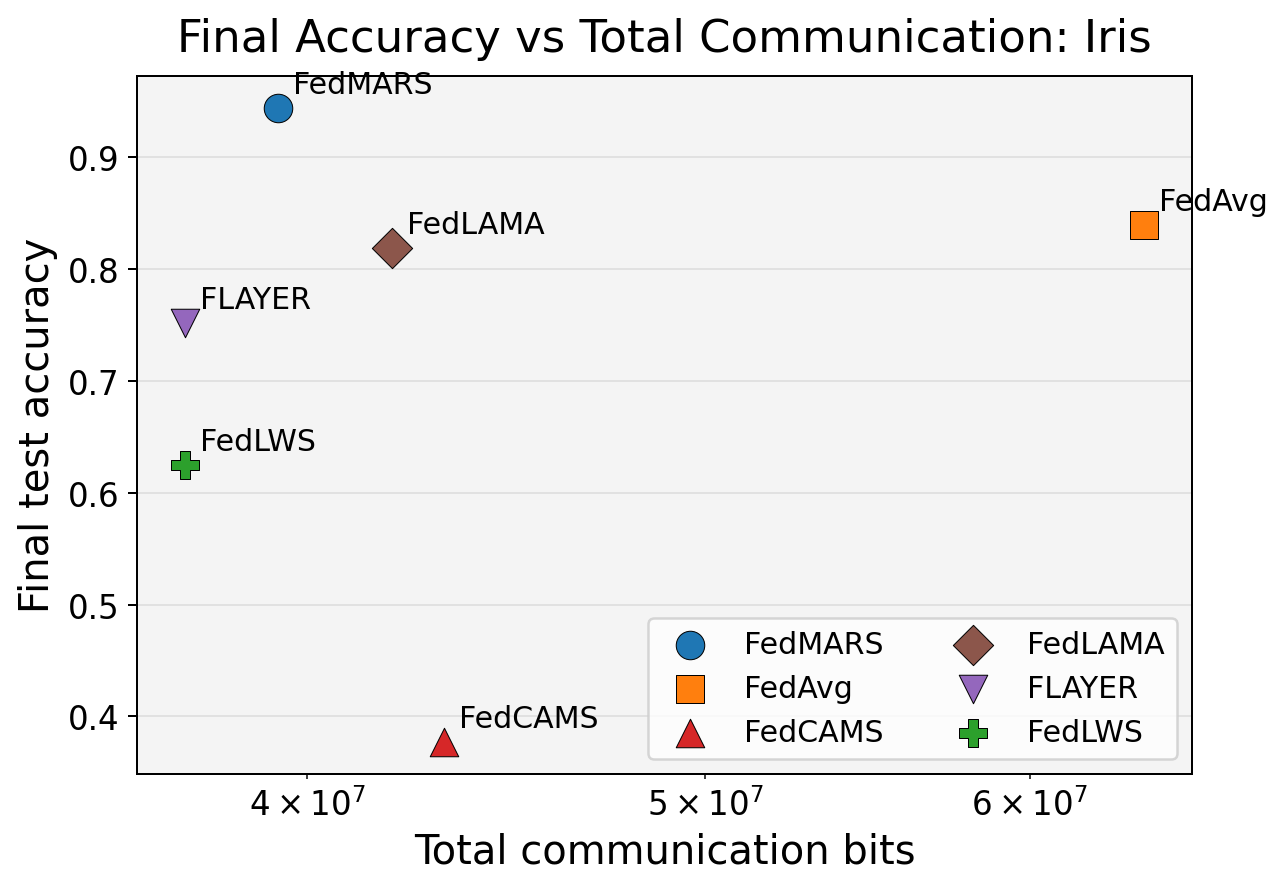

## Communication Selectivity Summary

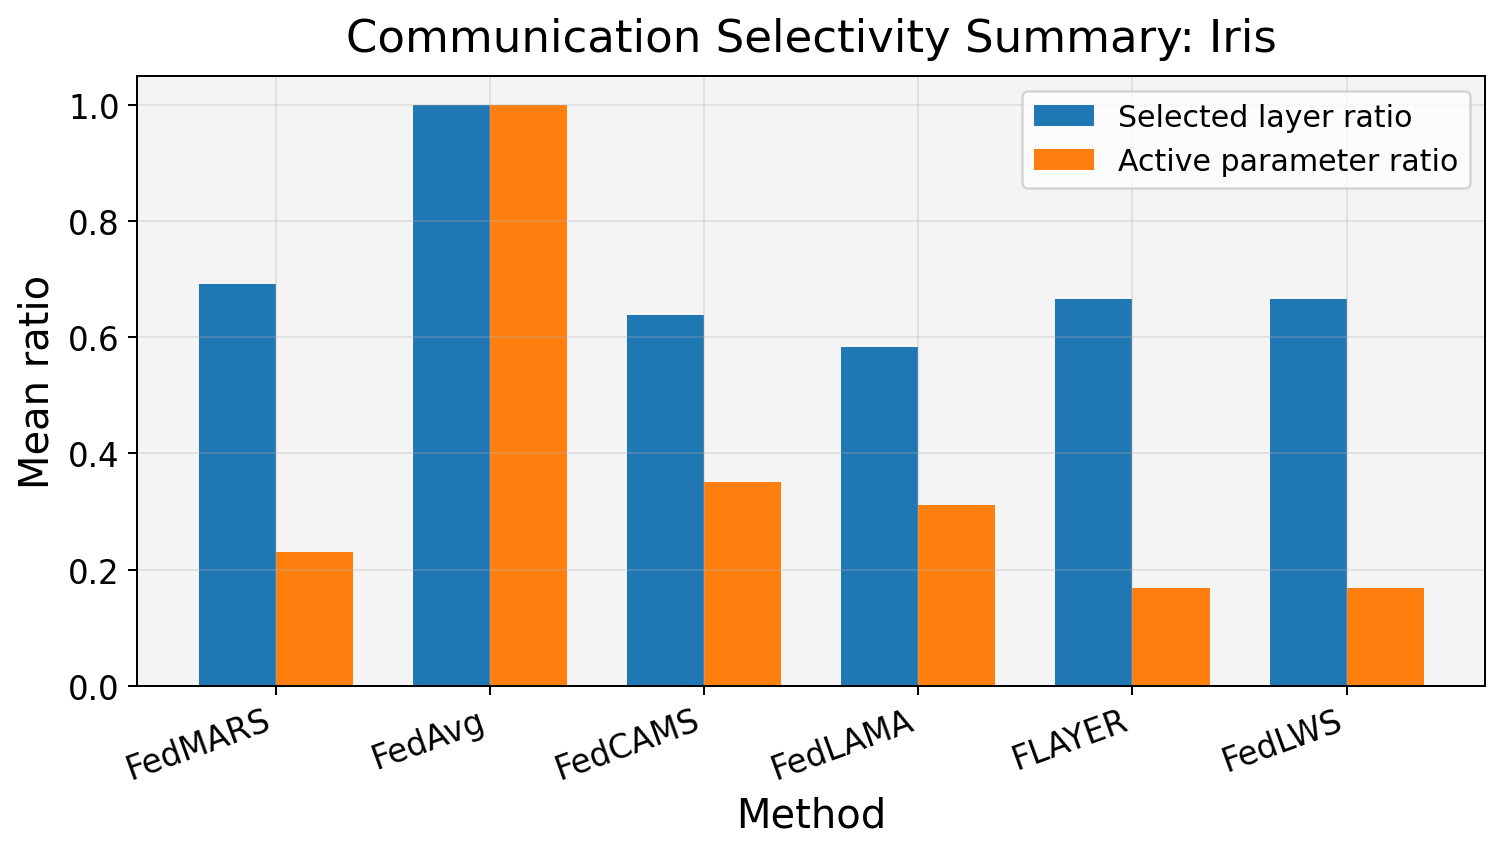

## Validation Accuracy Under Increasing Statistical Heterogeneity

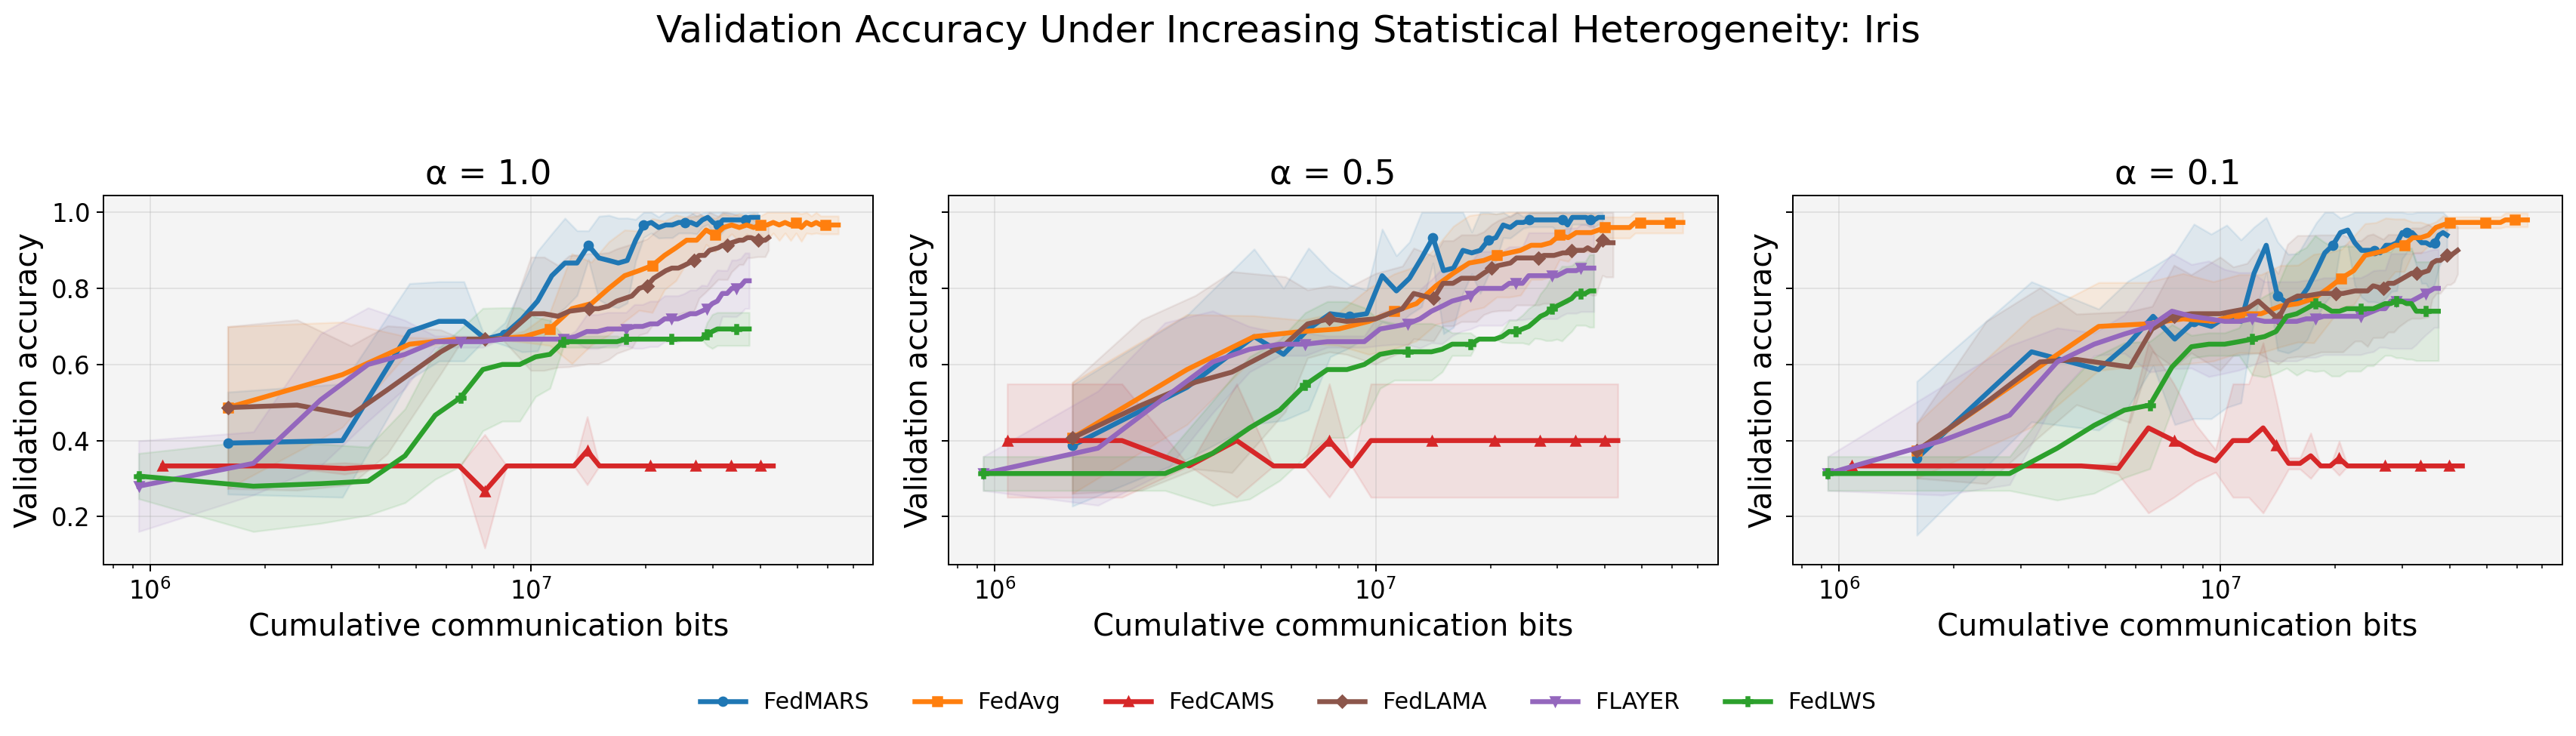

## Validation Accuracy Under Increasing Local Training

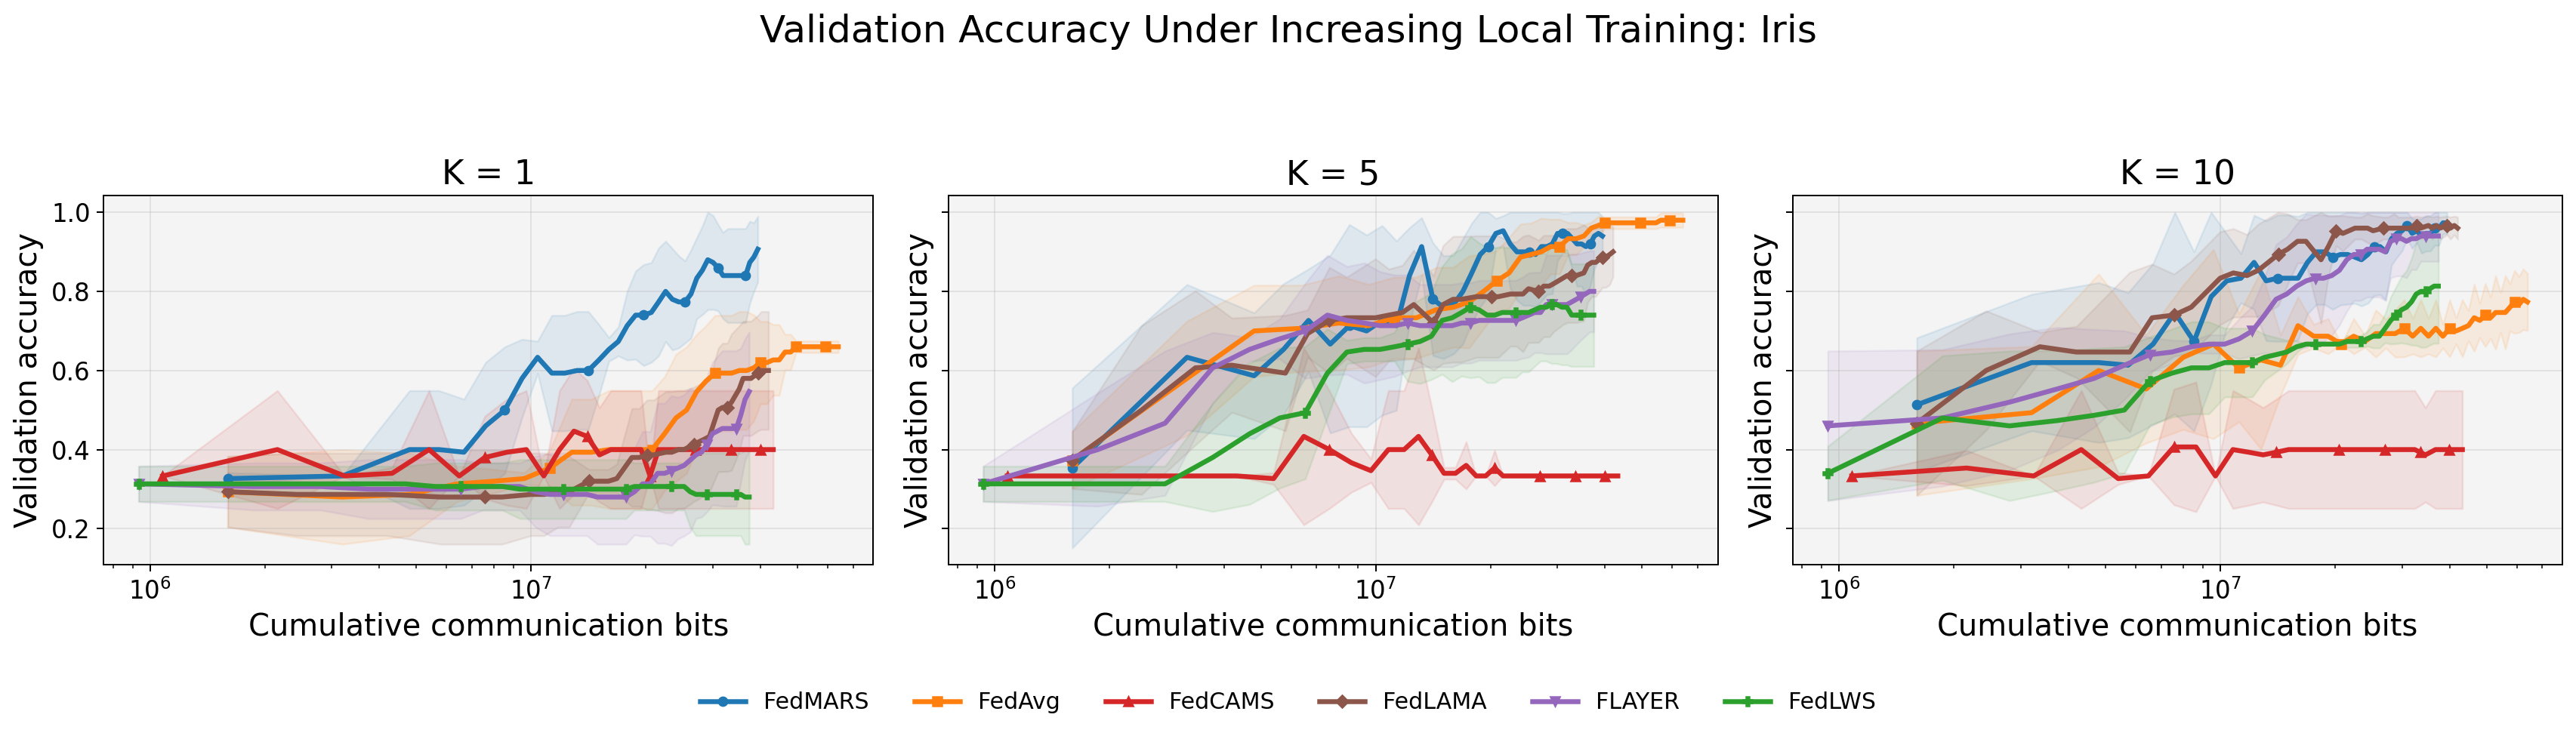

alpha=1.0, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

...

alpha=0.1, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

# Validation 3 — Balance Scale

## Accuracy and communication summary

,Method,Final test accuracy,Shared-budget accuracy,Total communication (Mbits),Selected layer ratio,Active parameter ratio
0,FedMARS,0.9045 ± 0.0353,0.9092 ± 0.0354,39.34,0.691,0.230
1,FedAvg,0.8980 ± 0.0332,0.8796 ± 0.0373,63.97,1.000,1.000
2,FedCAMS,0.5230 ± 0.1328,0.6756 ± 0.1694,43.19,0.666,0.350
3,FedLAMA,0.8747 ± 0.0340,0.8757 ± 0.0387,41.96,0.583,0.312
4,FLAYER,0.8418 ± 0.0666,0.8432 ± 0.0554,37.35,0.667,0.168
5,FedLWS,0.8030 ± 0.1040,0.8064 ± 0.0926,37.35,0.667,0.168


## Final Accuracy vs Total Communication

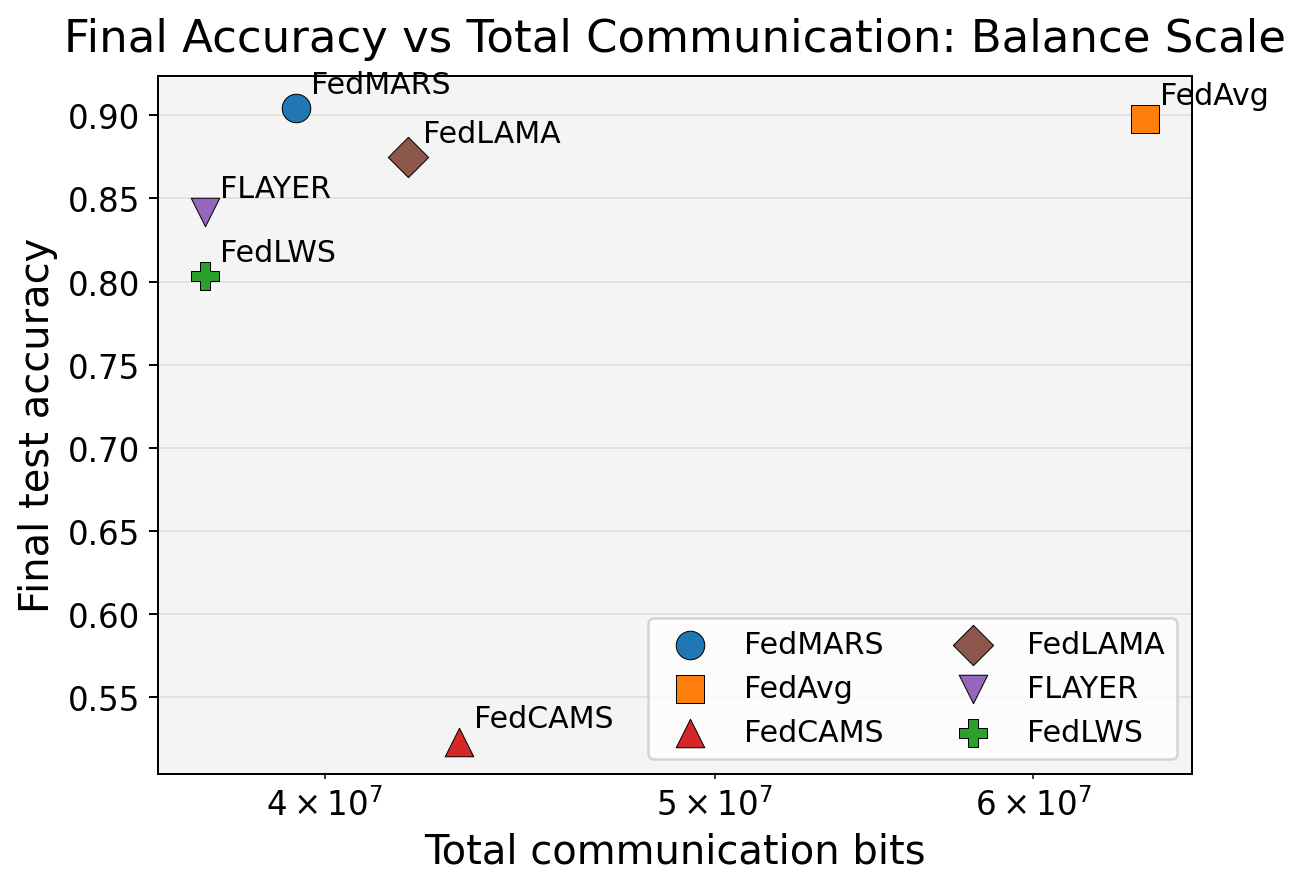

## Communication Selectivity Summary

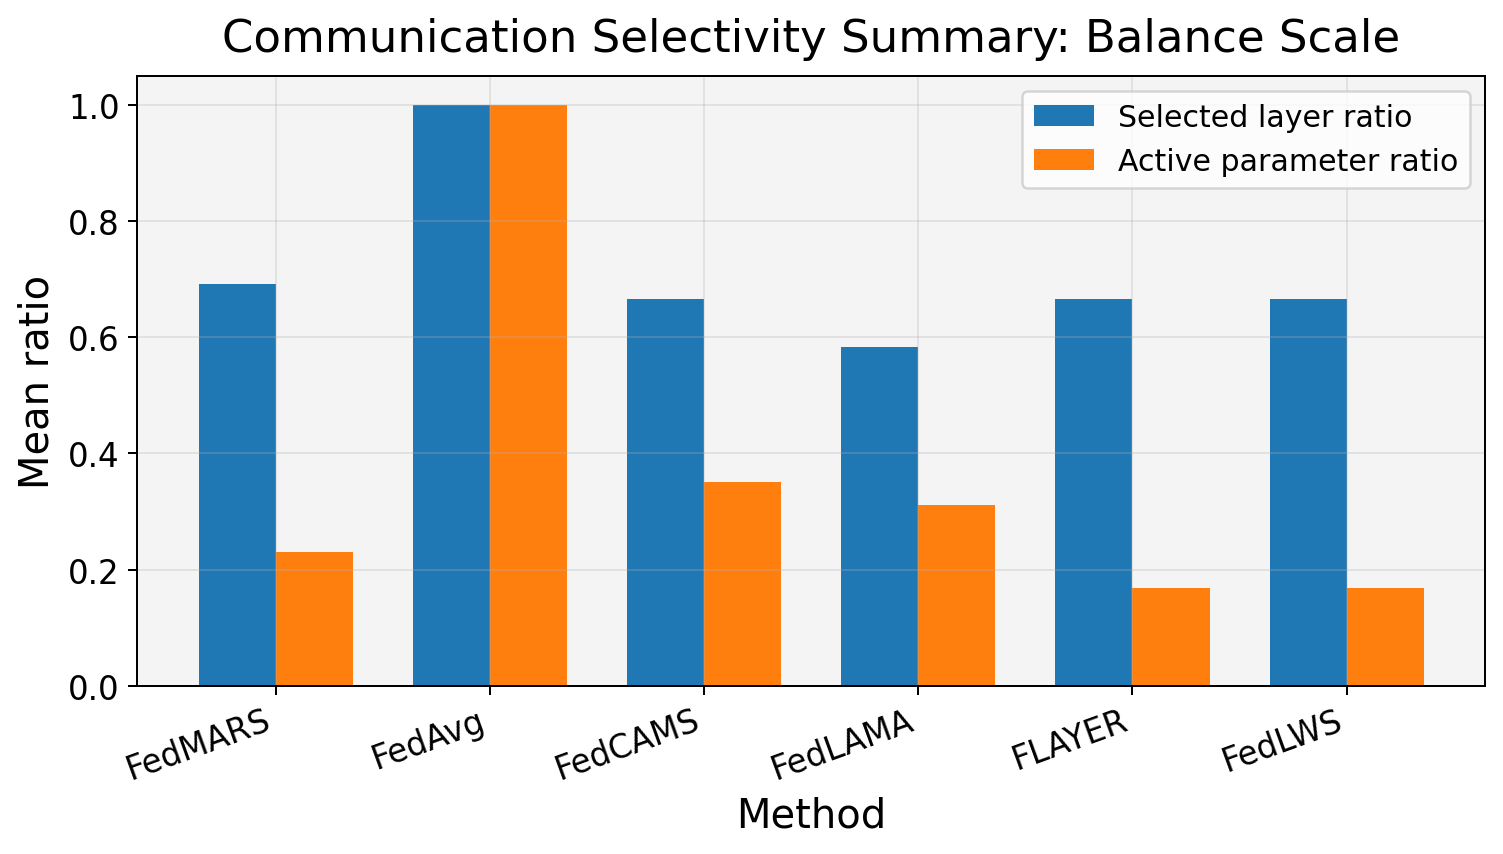

## Validation Accuracy Under Increasing Statistical Heterogeneity

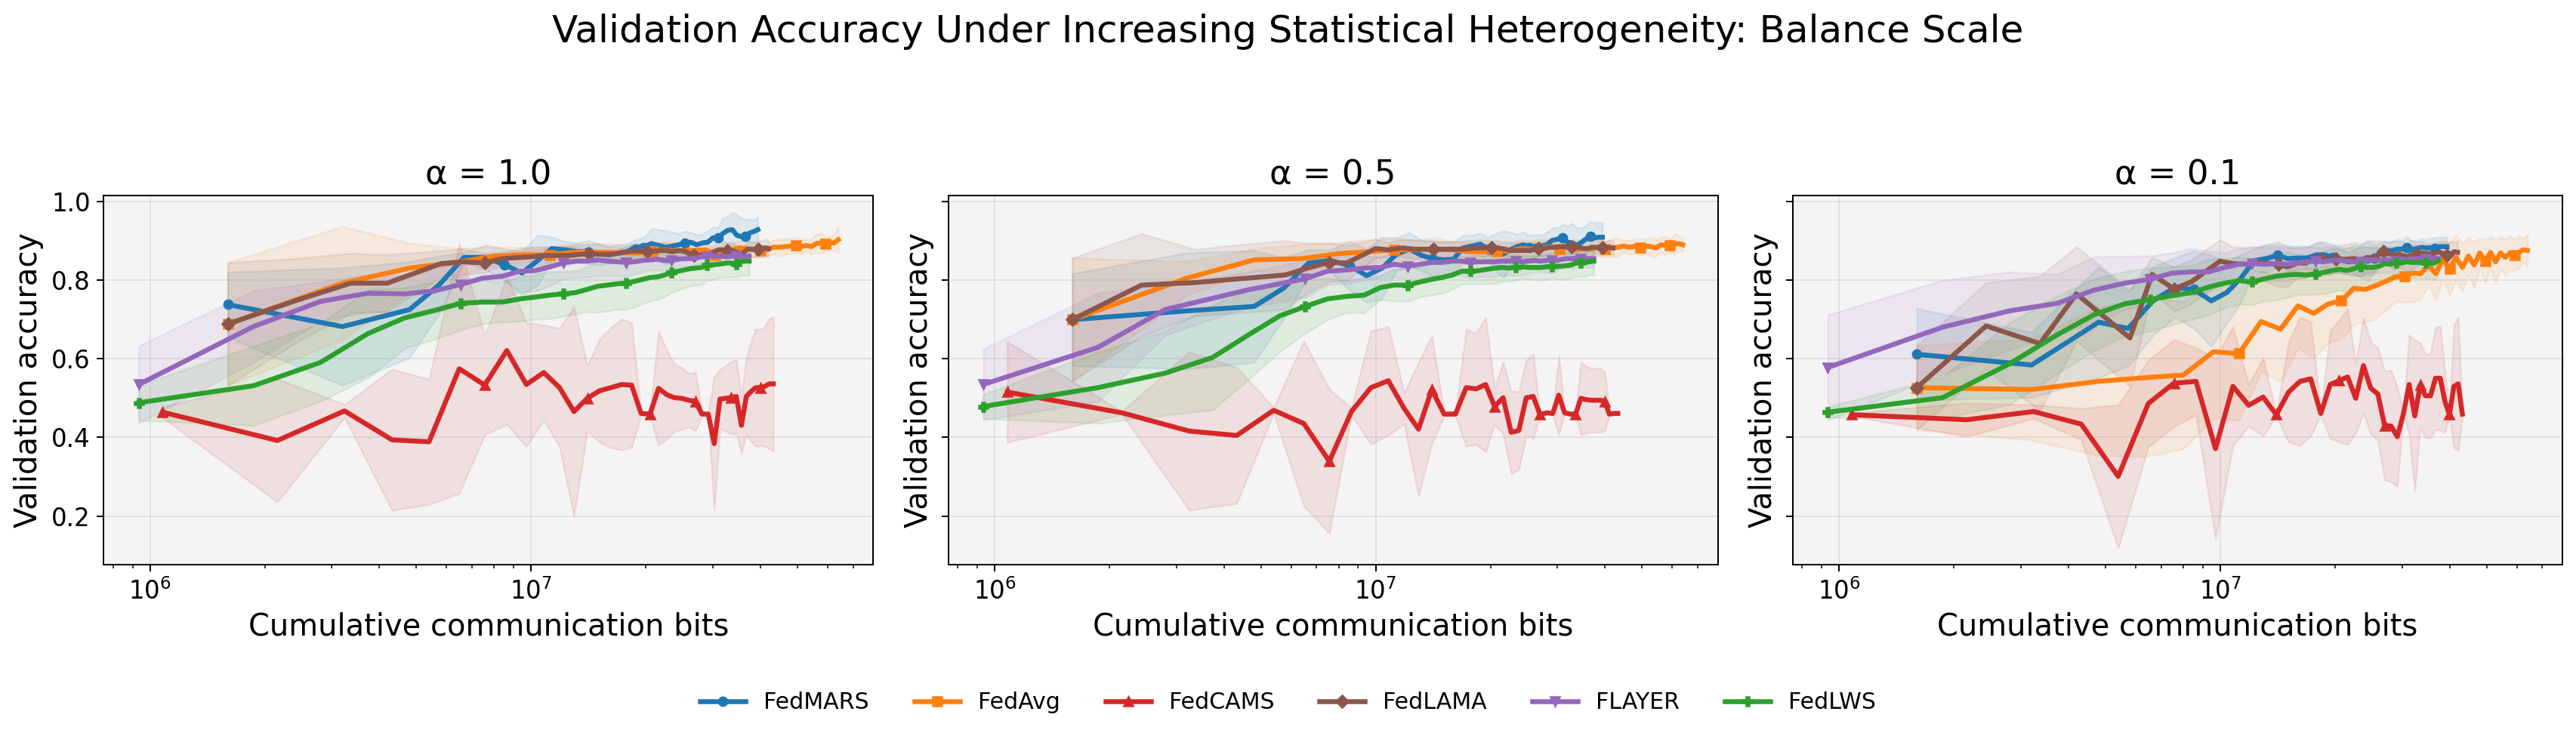

## Validation Accuracy Under Increasing Local Training

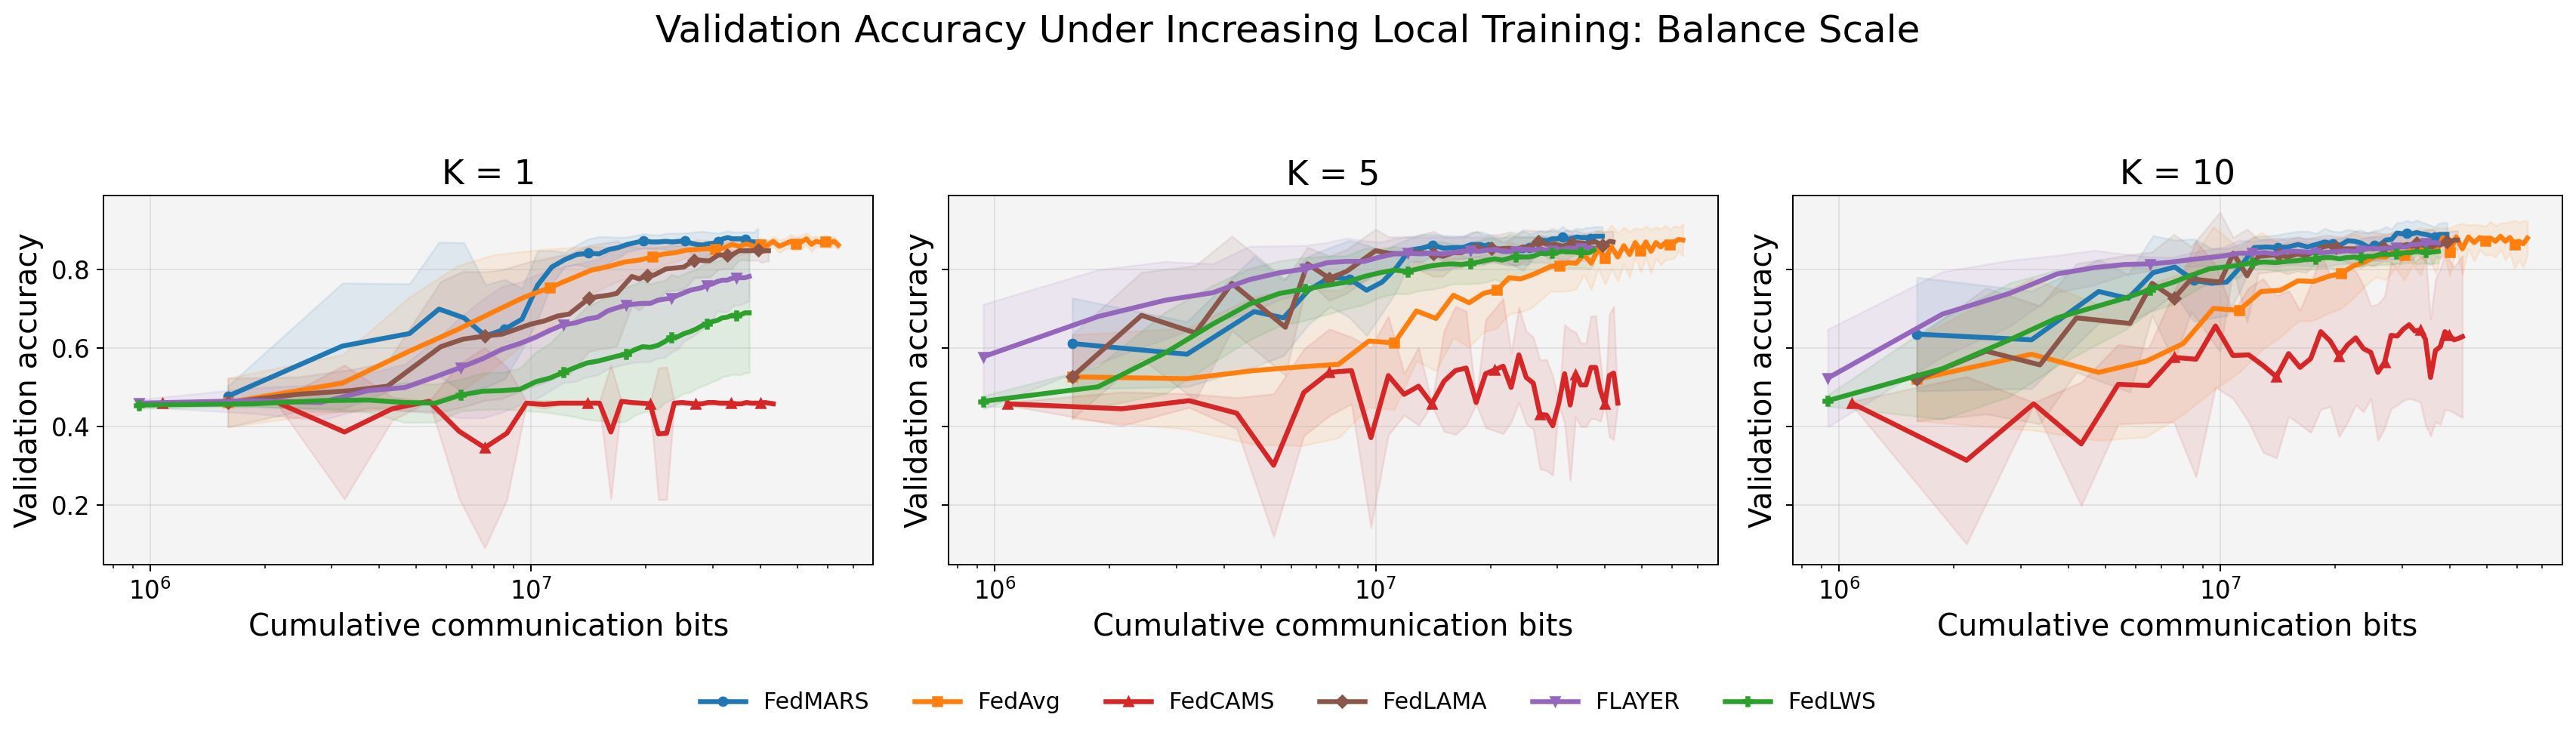

alpha=1.0, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=0.5, E=5:   0%|          | 0/5 [00:00<?, ?it/s]

...

alpha=0.1, E=10:   0%|          | 0/5 [00:00<?, ?it/s]

# Validation 3 — Vertebral Column

## Accuracy and communication summary

,Method,Final test accuracy,Shared-budget accuracy,Total communication (Mbits),Selected layer ratio,Active parameter ratio
0,FedMARS,0.7731 ± 0.0455,0.8308 ± 0.0301,42.52,0.686,0.264
1,FedAvg,0.7430 ± 0.0511,0.7957 ± 0.0421,67.25,1.000,1.000
2,FedCAMS,0.4541 ± 0.1060,0.6115 ± 0.1204,45.39,0.589,0.350
3,FedLAMA,0.7538 ± 0.0604,0.8082 ± 0.0426,44.42,0.583,0.321
4,FLAYER,0.7642 ± 0.0677,0.8068 ± 0.0429,40.63,0.667,0.208
5,FedLWS,0.7416 ± 0.0713,0.7835 ± 0.0624,40.63,0.667,0.208


## Final Accuracy vs Total Communication

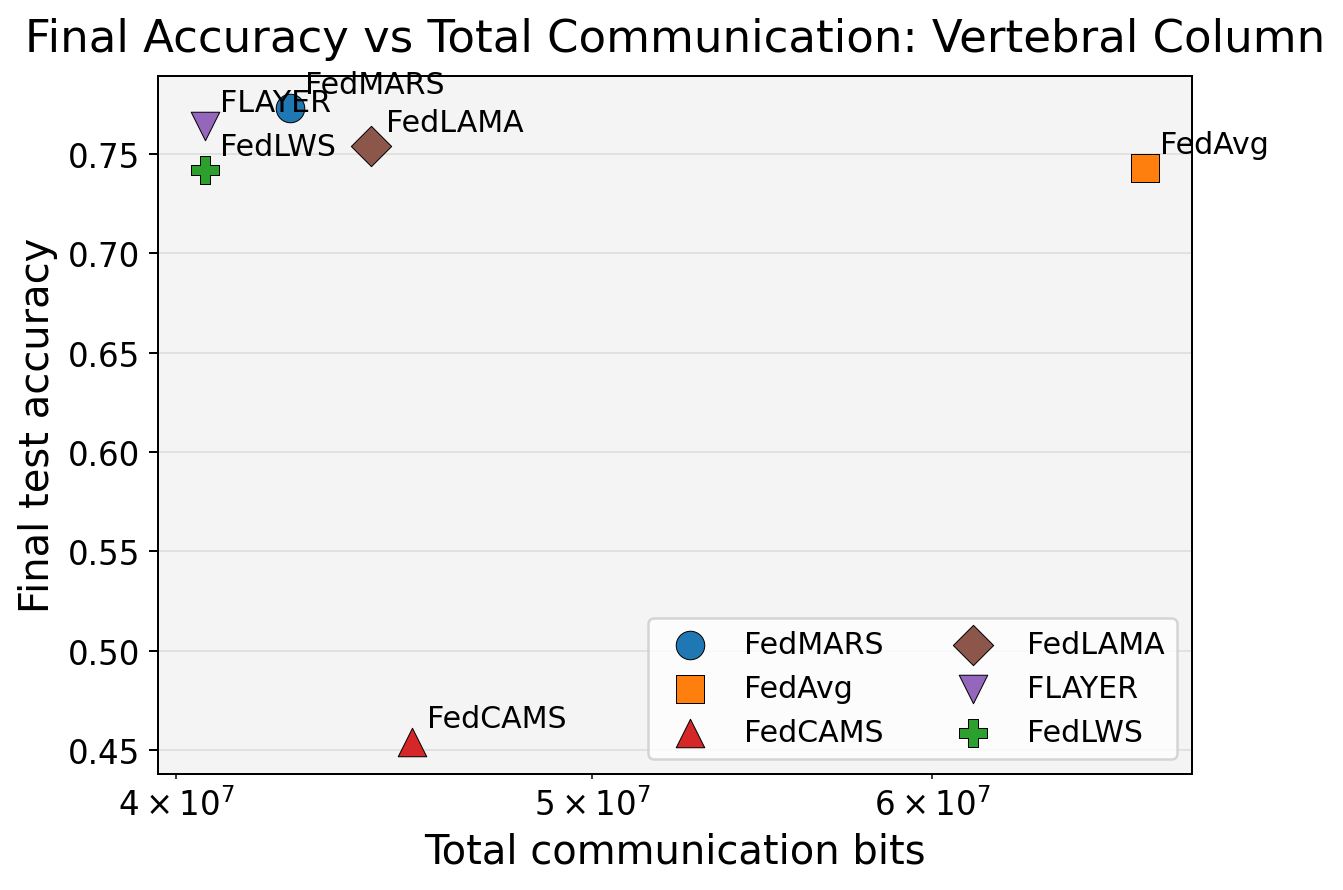

## Communication Selectivity Summary

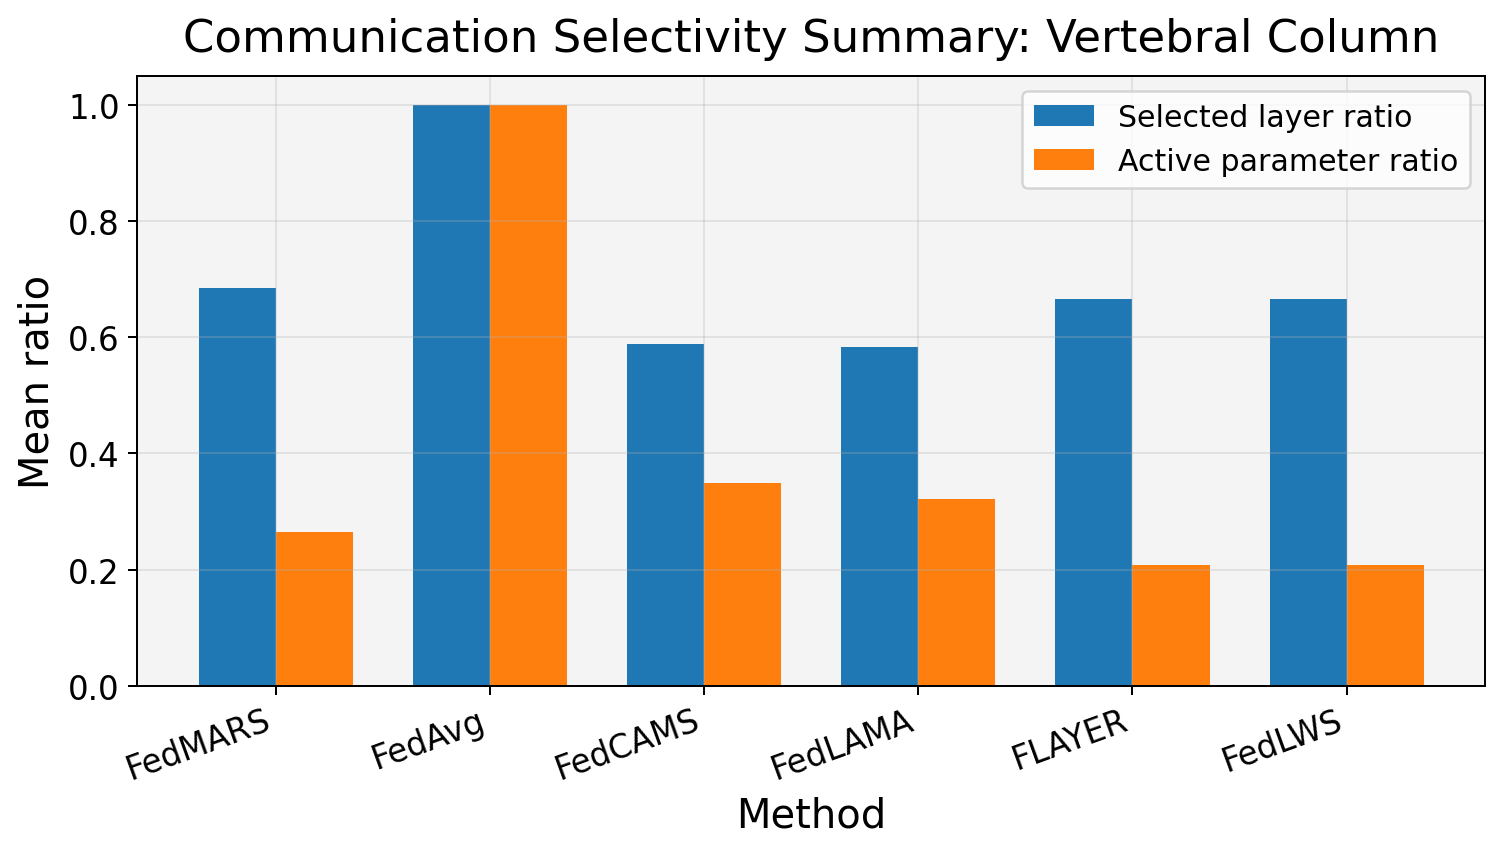

## Validation Accuracy Under Increasing Statistical Heterogeneity

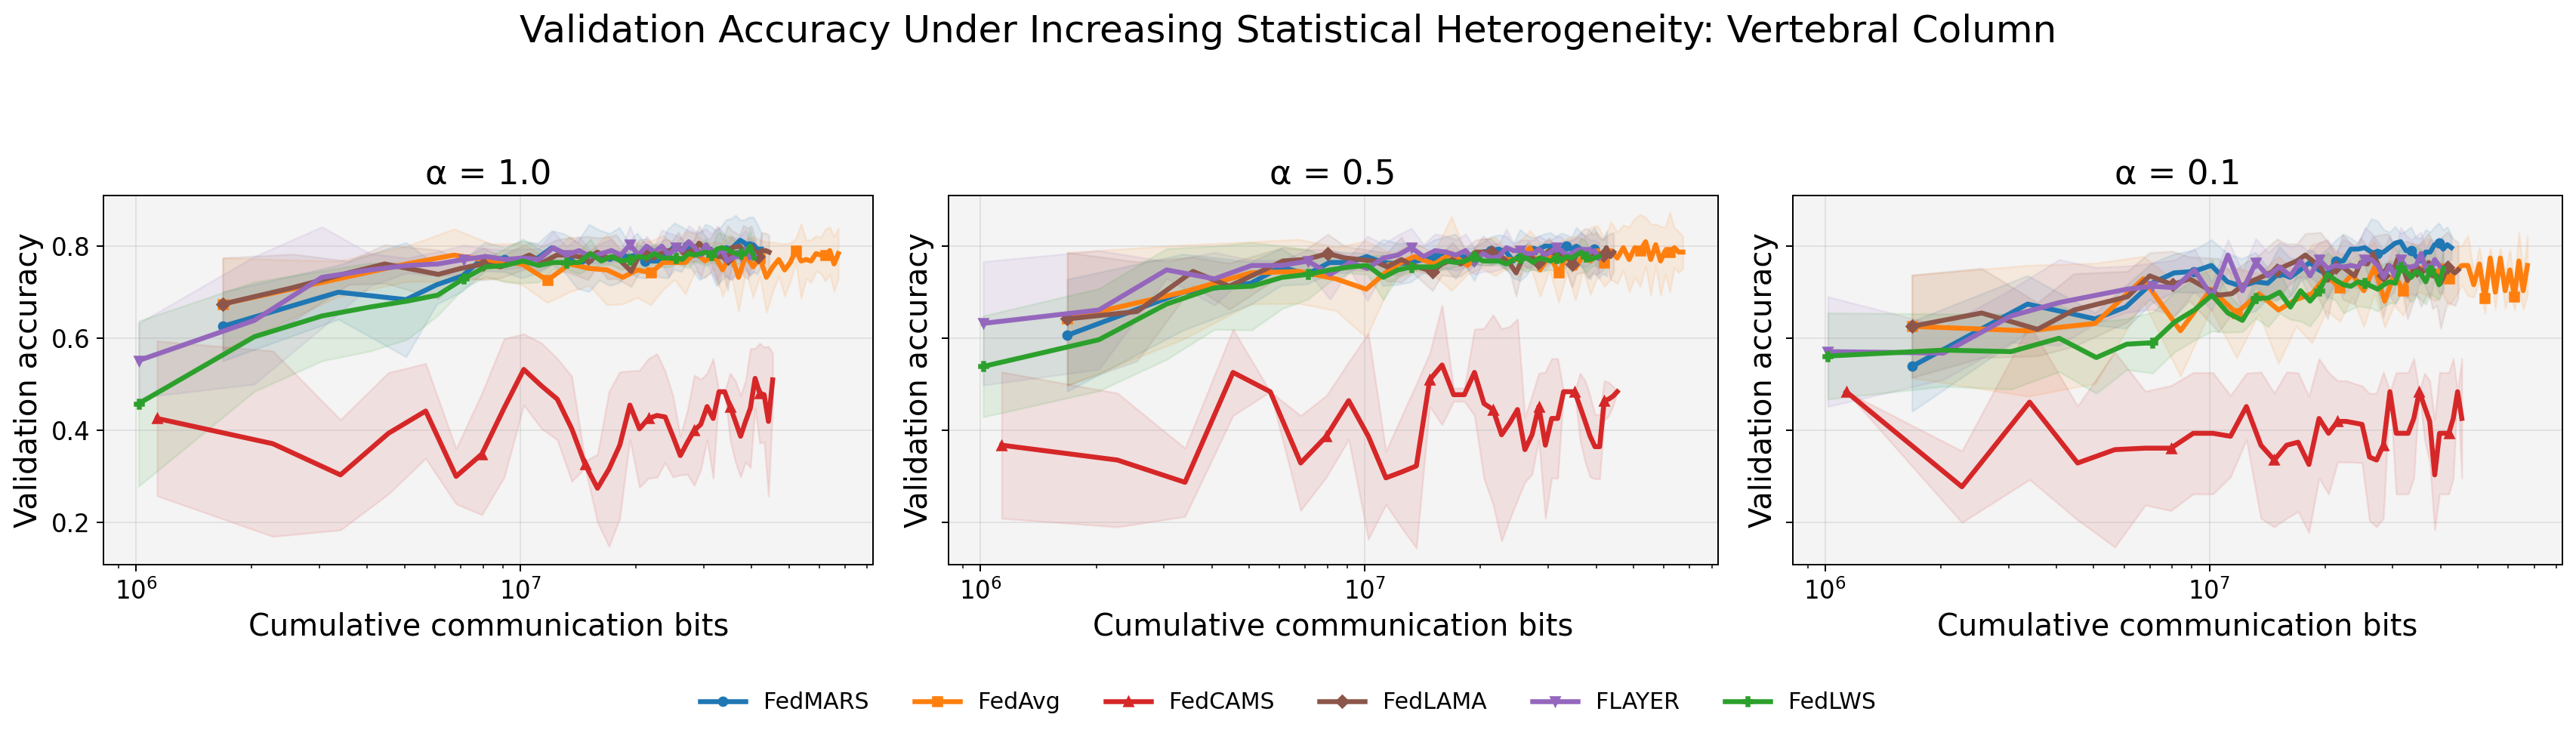

## Validation Accuracy Under Increasing Local Training

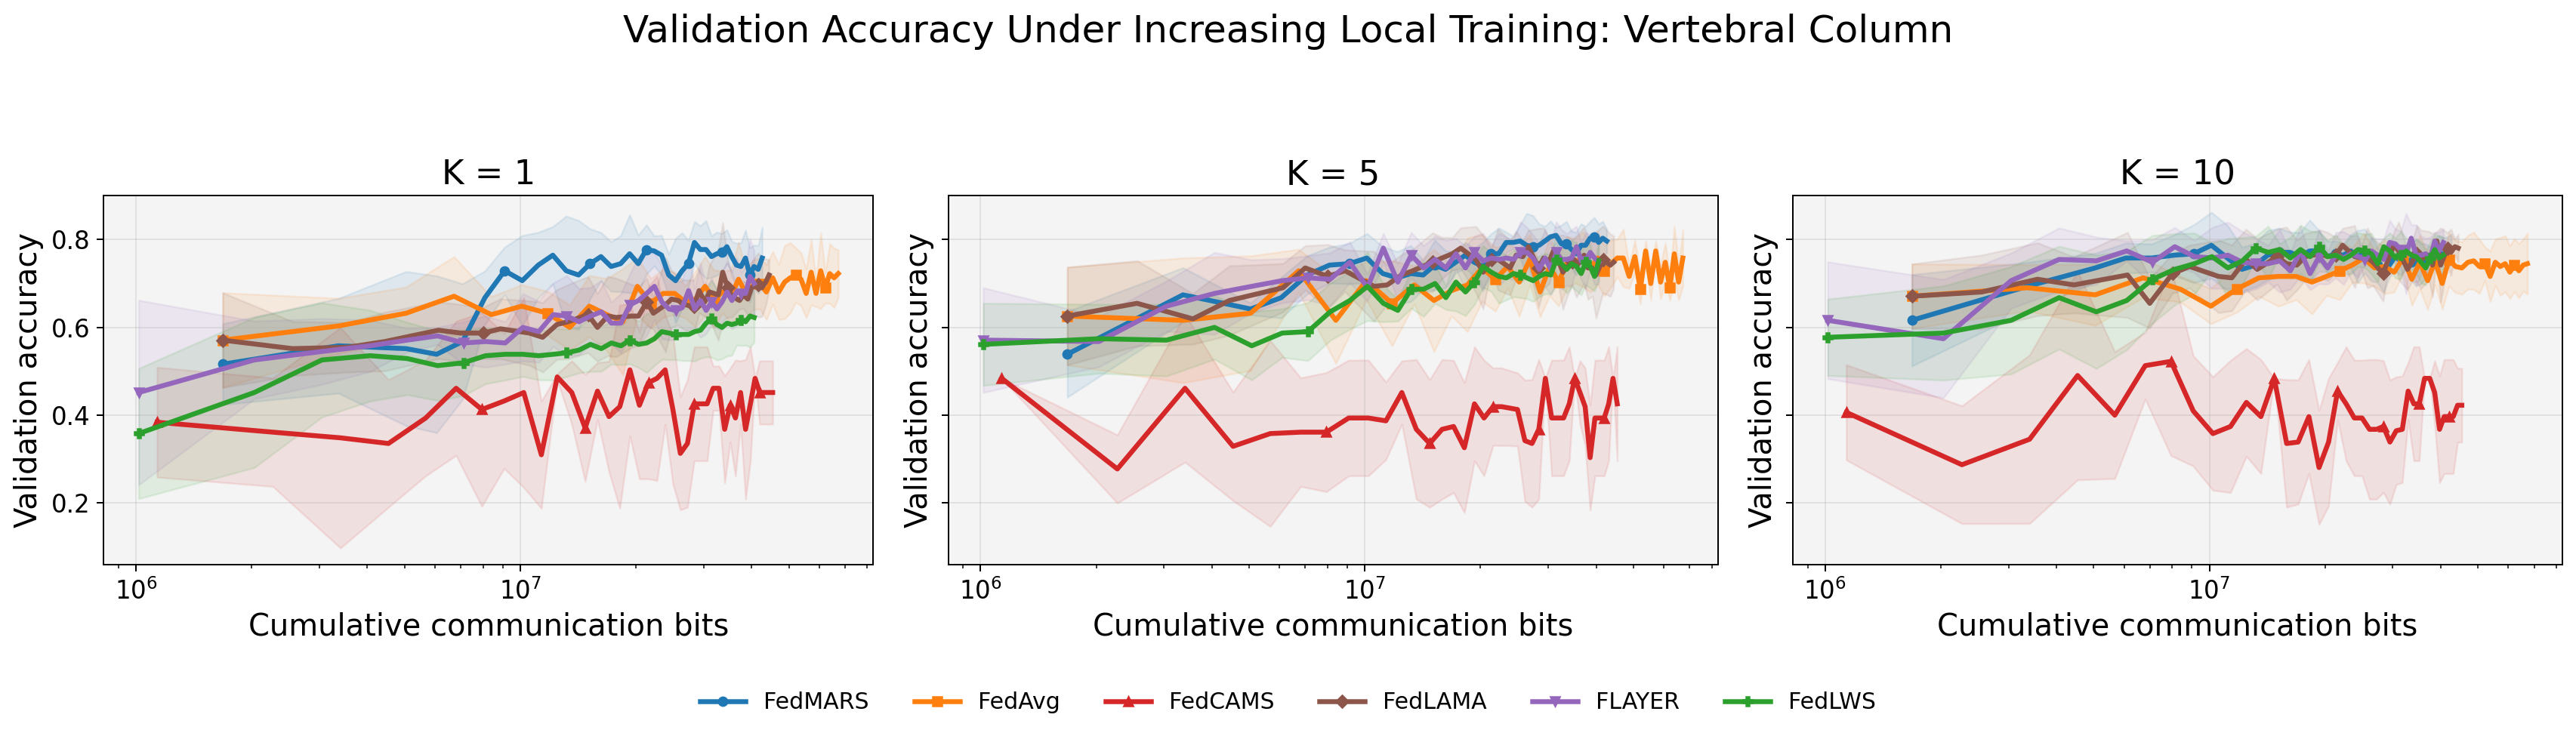

# Validation 3 main-paper table

,Dataset,FedMARS final acc.,Best baseline final acc.,FedMARS shared-budget acc.,Best baseline shared-budget acc.,FedMARS total comm. (Mbits),FedMARS selected layer ratio,FedMARS active parameter ratio
0,Iris,0.9444 ± 0.0550,FedAvg (0.8393),0.9504 ± 0.0737,FedAvg (0.8274),39.35,0.692,0.230
1,Balance Scale,0.9045 ± 0.0353,FedAvg (0.8980),0.9092 ± 0.0354,FedAvg (0.8796),39.34,0.691,0.230
2,Vertebral Column,0.7731 ± 0.0455,FLAYER (0.7642),0.8308 ± 0.0301,FedLAMA (0.8082),42.52,0.686,0.264


# Validation 3 combined trade-off plot

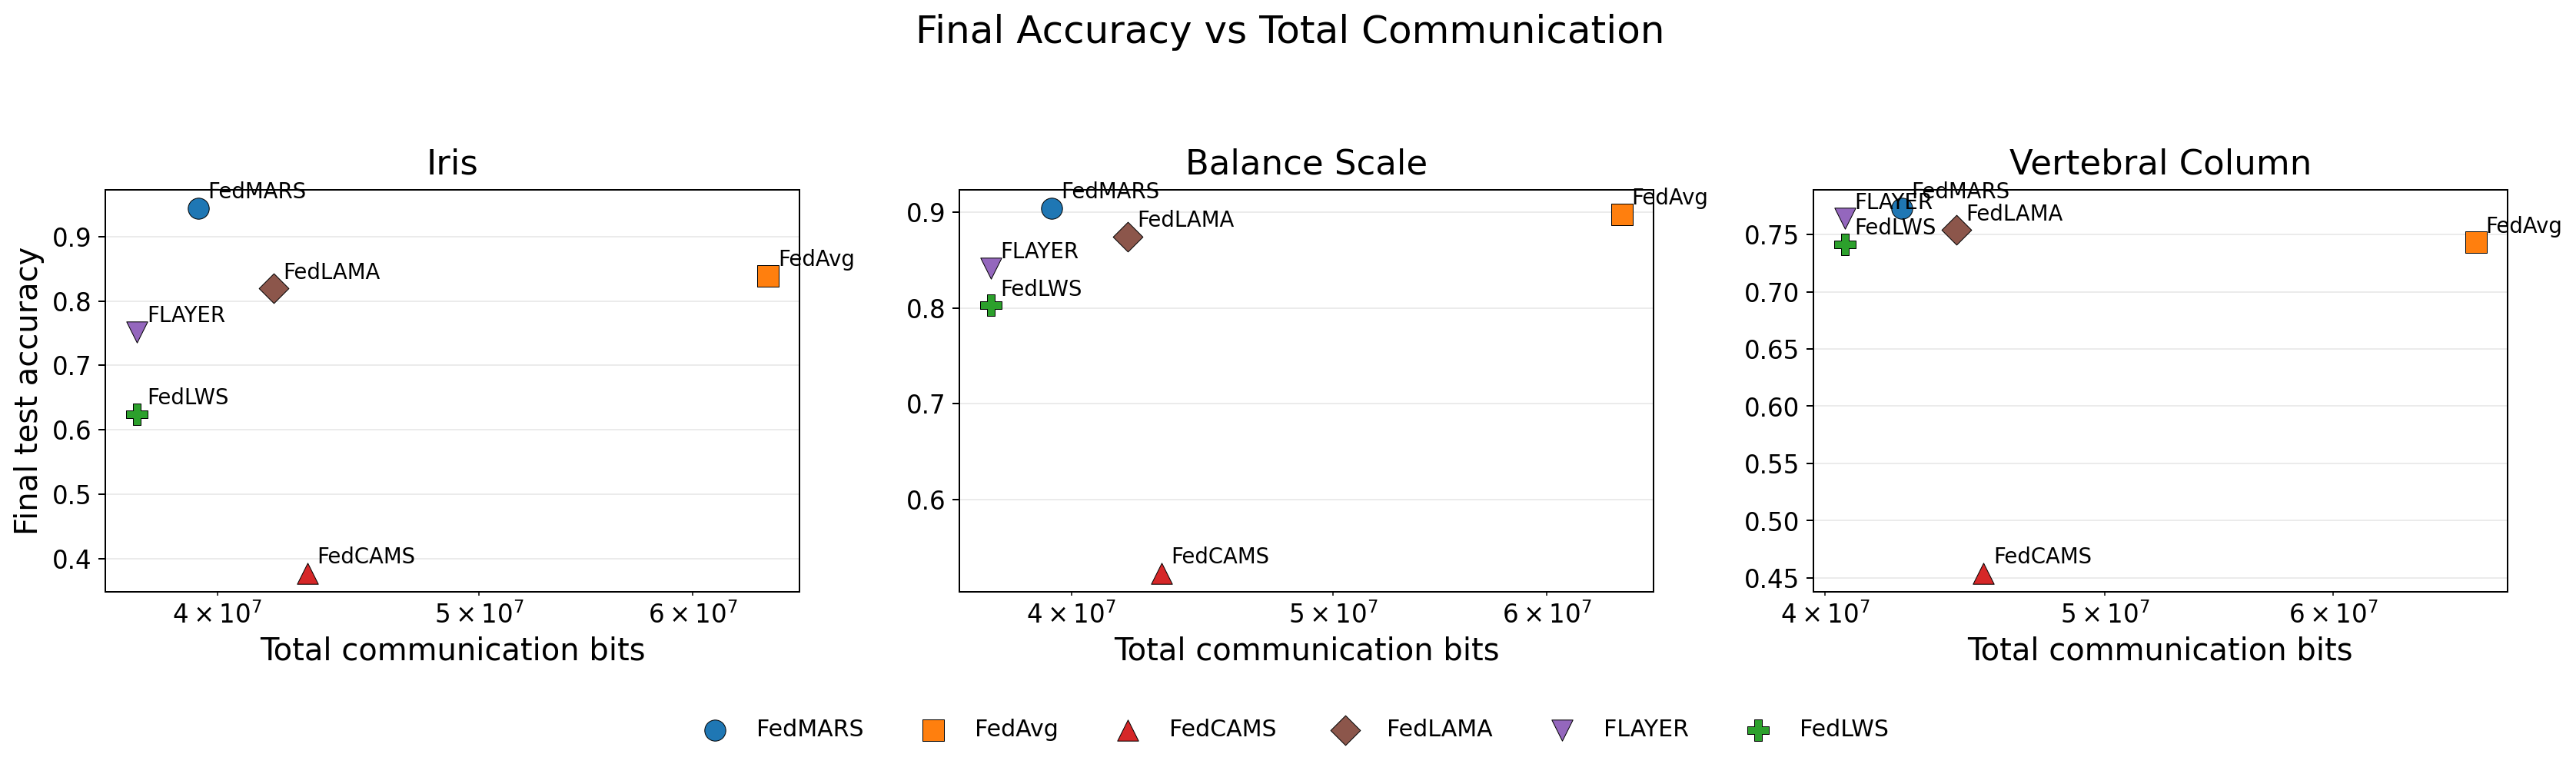

# FedMARS communication selectivity across datasets

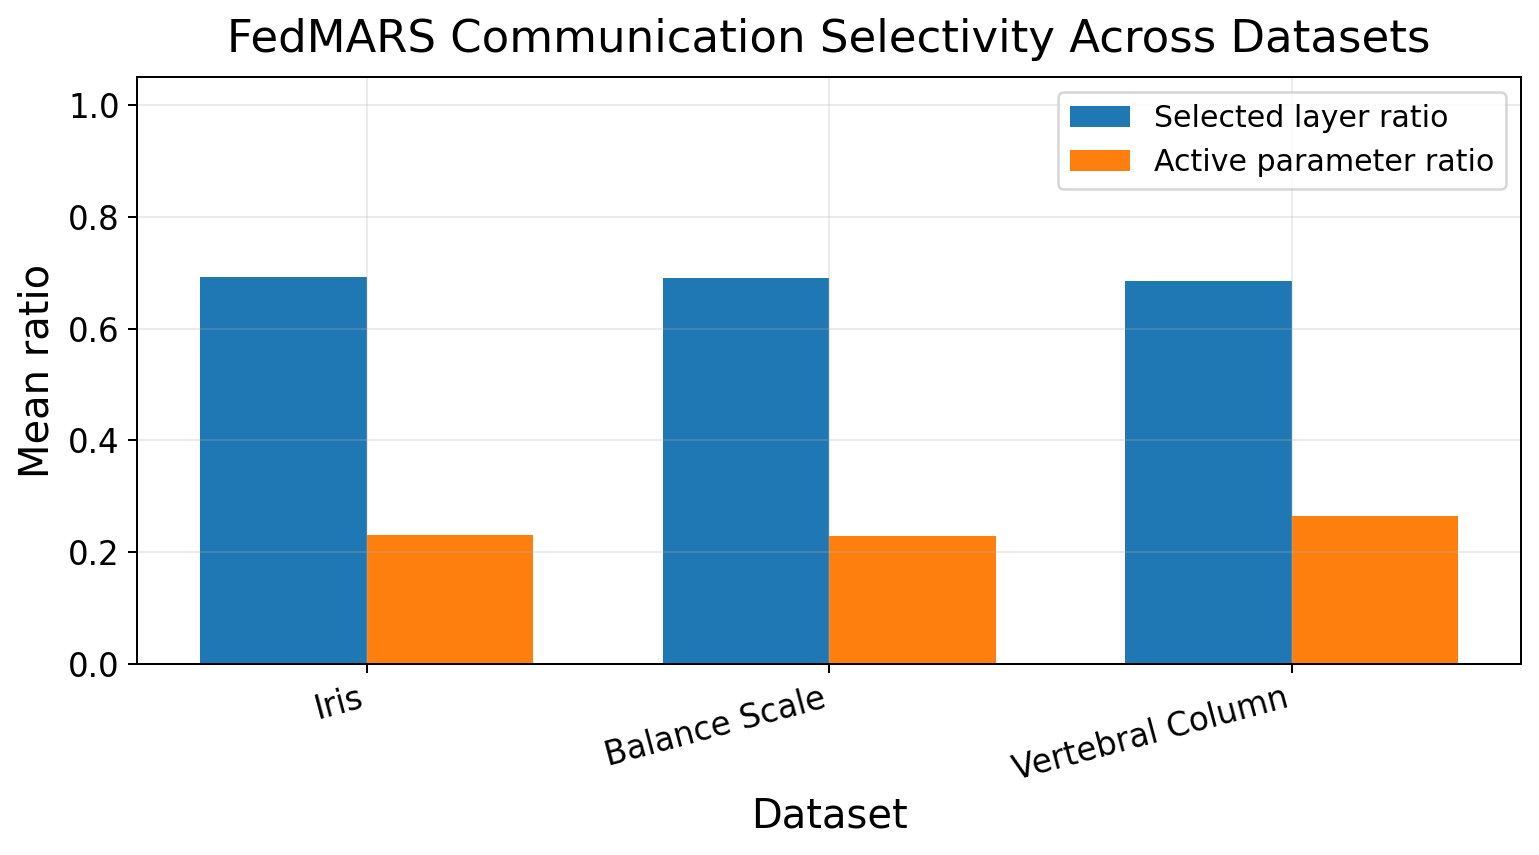

In [4]:
all_dataset_summaries = []
all_curve_summaries = []
all_dataset_errors = []

for dataset_idx, current_uci_id in enumerate(UCI_IDS, start=1):
    try:
        run_df, curve_df, summary_df, curve_mean_df, dataset_info = run_validation3(int(current_uci_id))
        dataset_name = str(dataset_info.get("dataset_name", f"UCI {int(current_uci_id)}")) if isinstance(dataset_info, dict) else f"UCI {int(current_uci_id)}"

        display(Markdown(f"# Validation 3 — {dataset_name}"))
        display(Markdown("## Accuracy and communication summary"))
        display(make_v3_single_dataset_table(summary_df))

        display(Markdown("## Final Accuracy vs Total Communication"))
        plot_final_accuracy_vs_total_bits(summary_df, dataset_name=dataset_name)

        display(Markdown("## Communication Selectivity Summary"))
        plot_selectivity(summary_df, dataset_name=dataset_name)

        display(Markdown("## Validation Accuracy Under Increasing Statistical Heterogeneity"))
        plot_heterogeneity_accuracy_vs_bits(curve_mean_df, fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG, dataset_name=dataset_name)

        display(Markdown("## Validation Accuracy Under Increasing Local Training"))
        plot_local_training_accuracy_vs_bits(curve_mean_df, fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG, dataset_name=dataset_name)

        summary_copy = summary_df.copy()
        summary_copy.insert(0, "uci_id", int(current_uci_id))
        summary_copy.insert(1, "dataset_name", dataset_name)
        all_dataset_summaries.append(summary_copy)

        curve_copy = curve_mean_df.copy()
        curve_copy.insert(0, "uci_id", int(current_uci_id))
        curve_copy.insert(1, "dataset_name", dataset_name)
        all_curve_summaries.append(curve_copy)

    except Exception as e:
        all_dataset_errors.append(pd.DataFrame([{
            "uci_id": int(current_uci_id),
            "error_type": type(e).__name__,
            "error_message": str(e),
        }]))

if all_dataset_summaries:
    combined_summary_df = pd.concat(all_dataset_summaries, ignore_index=True)

    display(Markdown("# Validation 3 main-paper table"))
    display(make_v3_main_paper_table(combined_summary_df))

    display(Markdown("# Validation 3 combined trade-off plot"))
    plot_v3_combined_tradeoff(combined_summary_df)

    display(Markdown("# FedMARS communication selectivity across datasets"))
    plot_v3_fedmars_selectivity_by_dataset(combined_summary_df)

if all_dataset_errors:
    display(Markdown("# Dataset runs with errors"))
    display(pd.concat(all_dataset_errors, ignore_index=True))


**Plot fix**

### Dataset: Iris

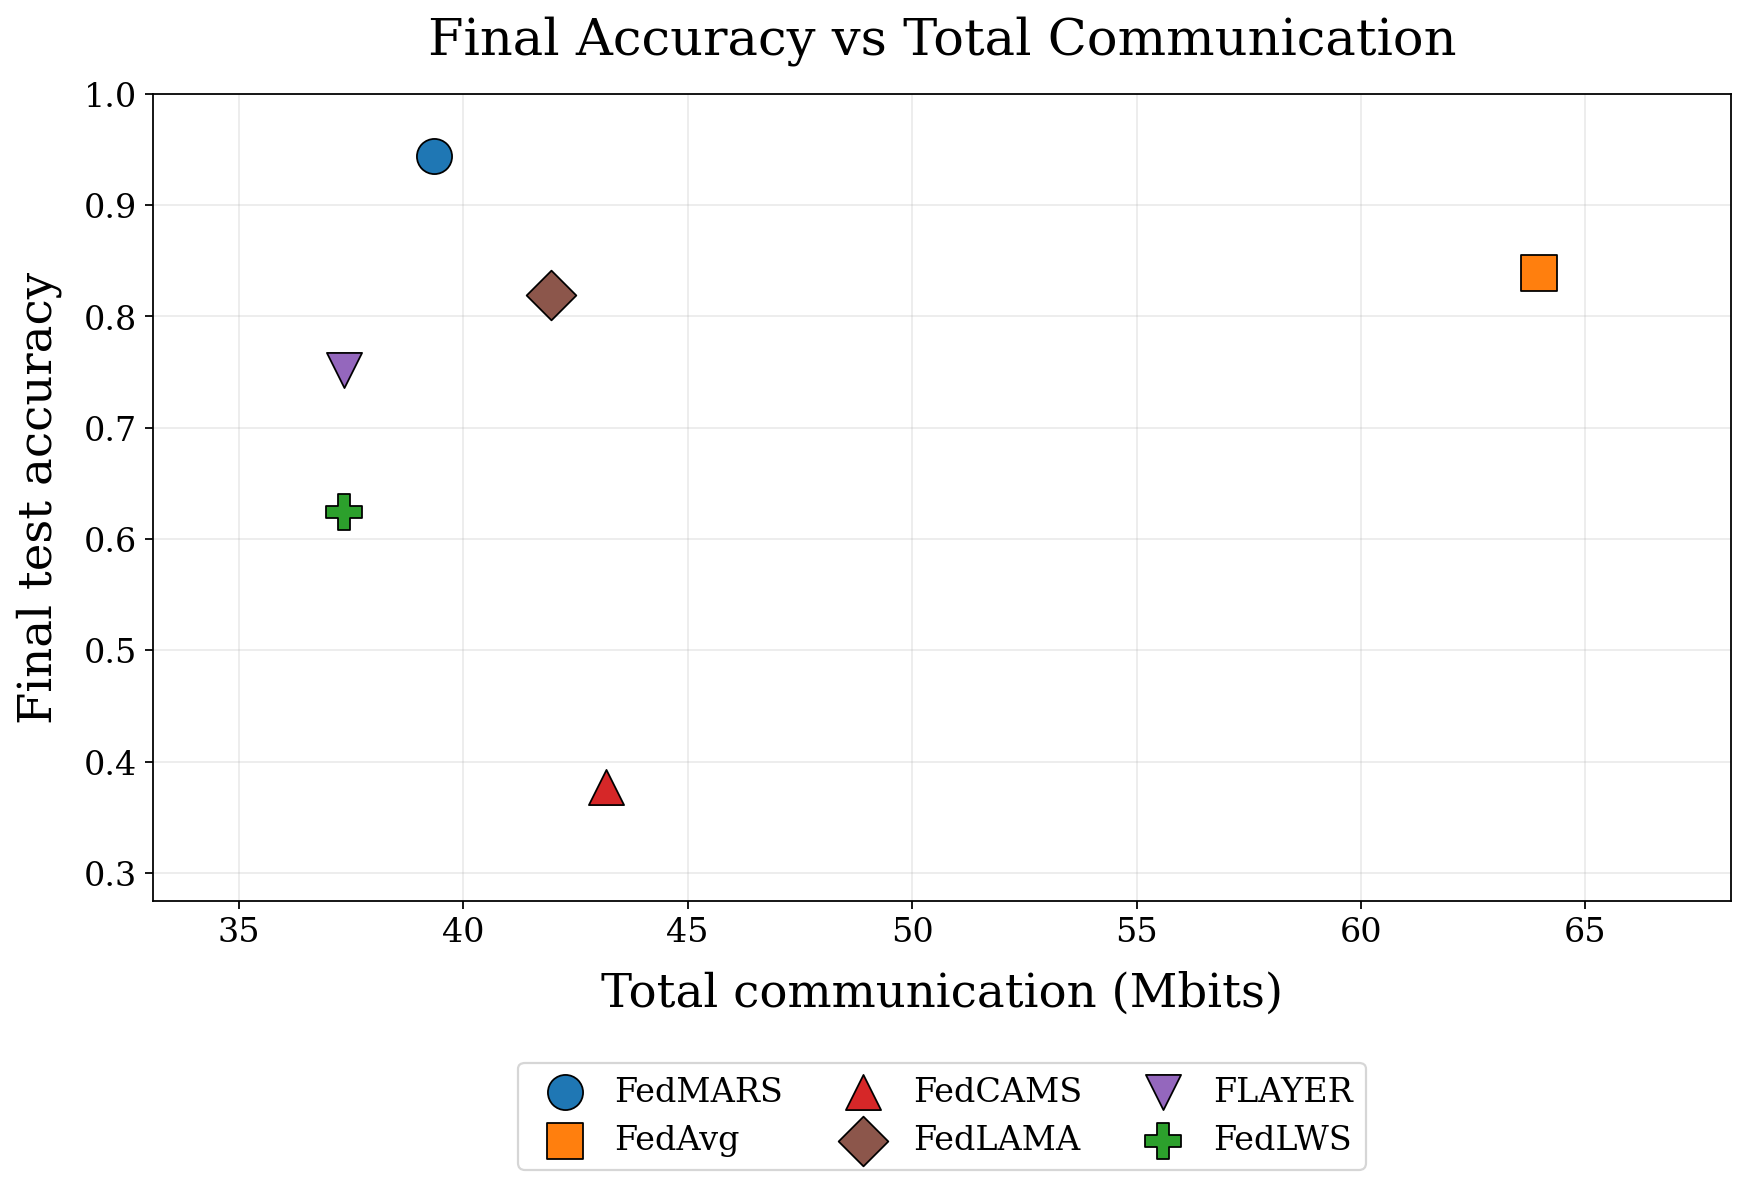

### Dataset: Balance Scale

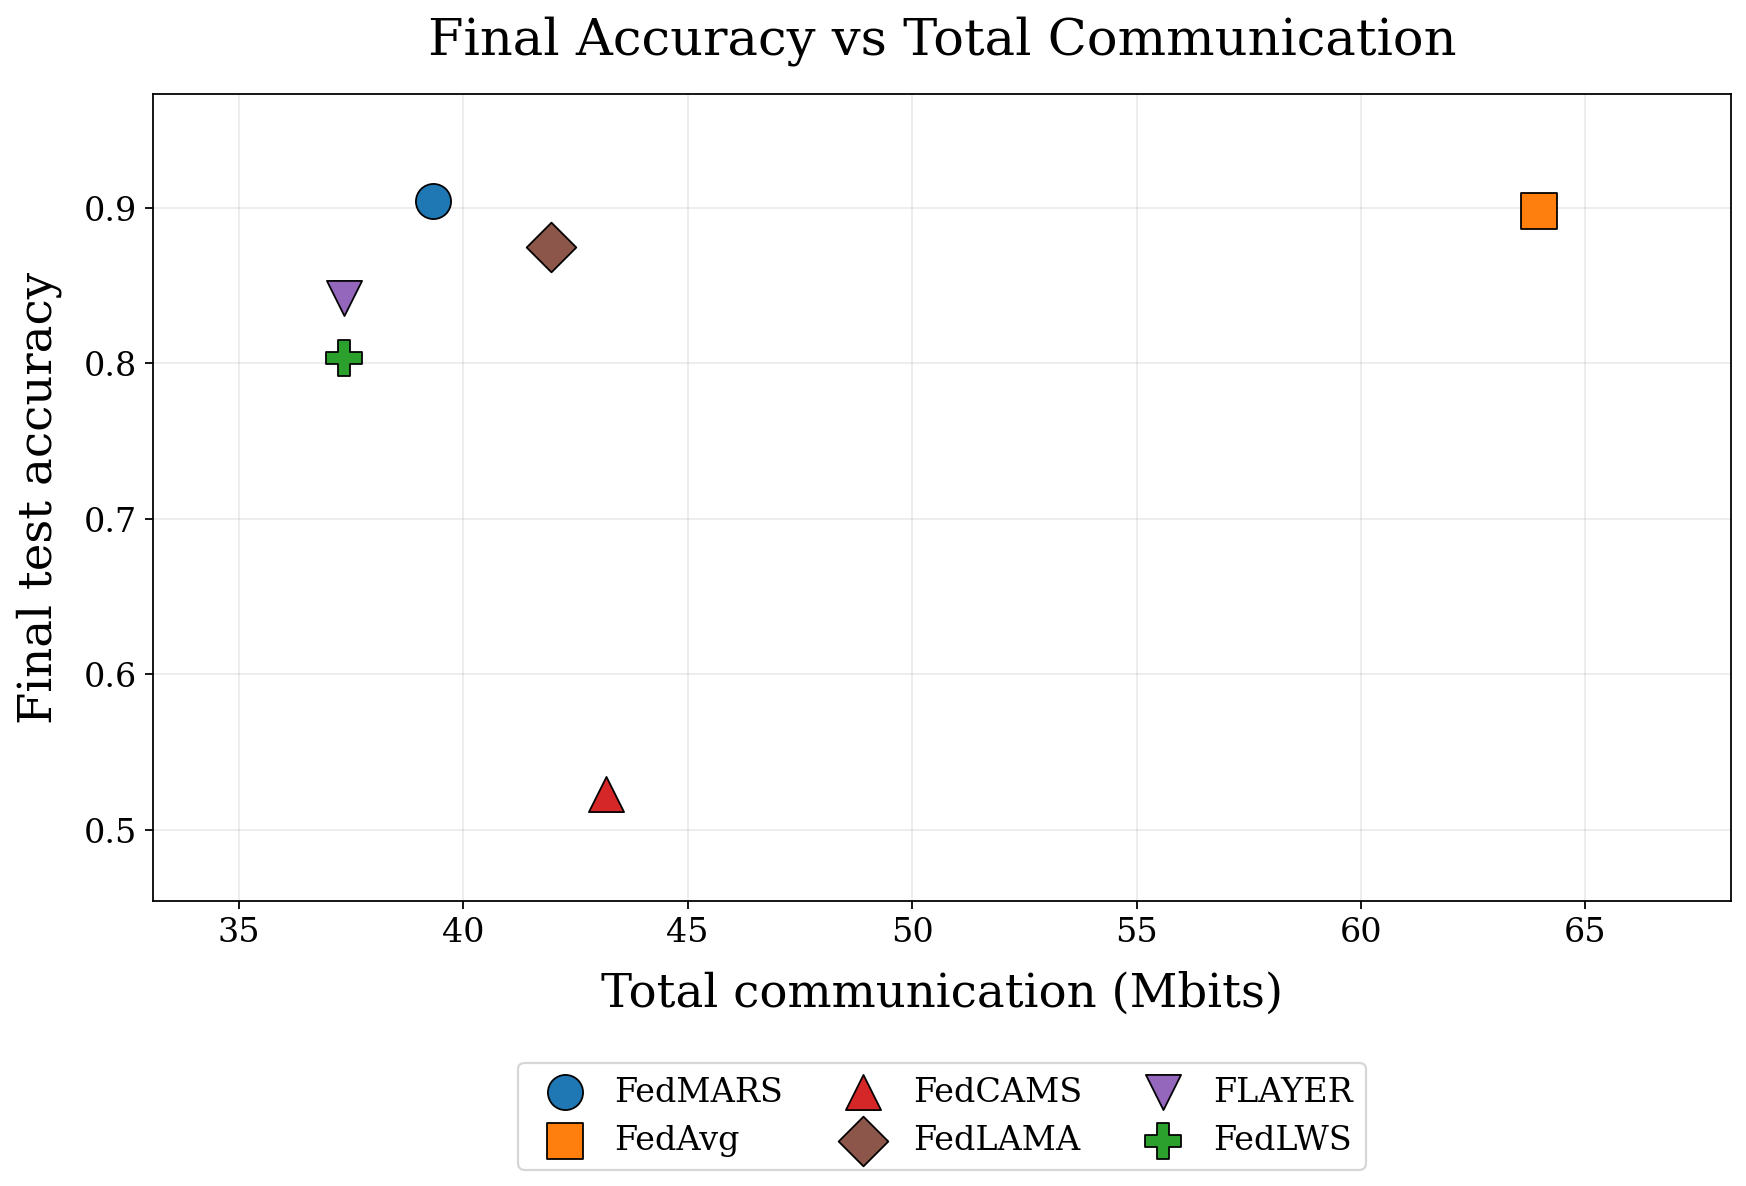

### Dataset: Vertebral Column

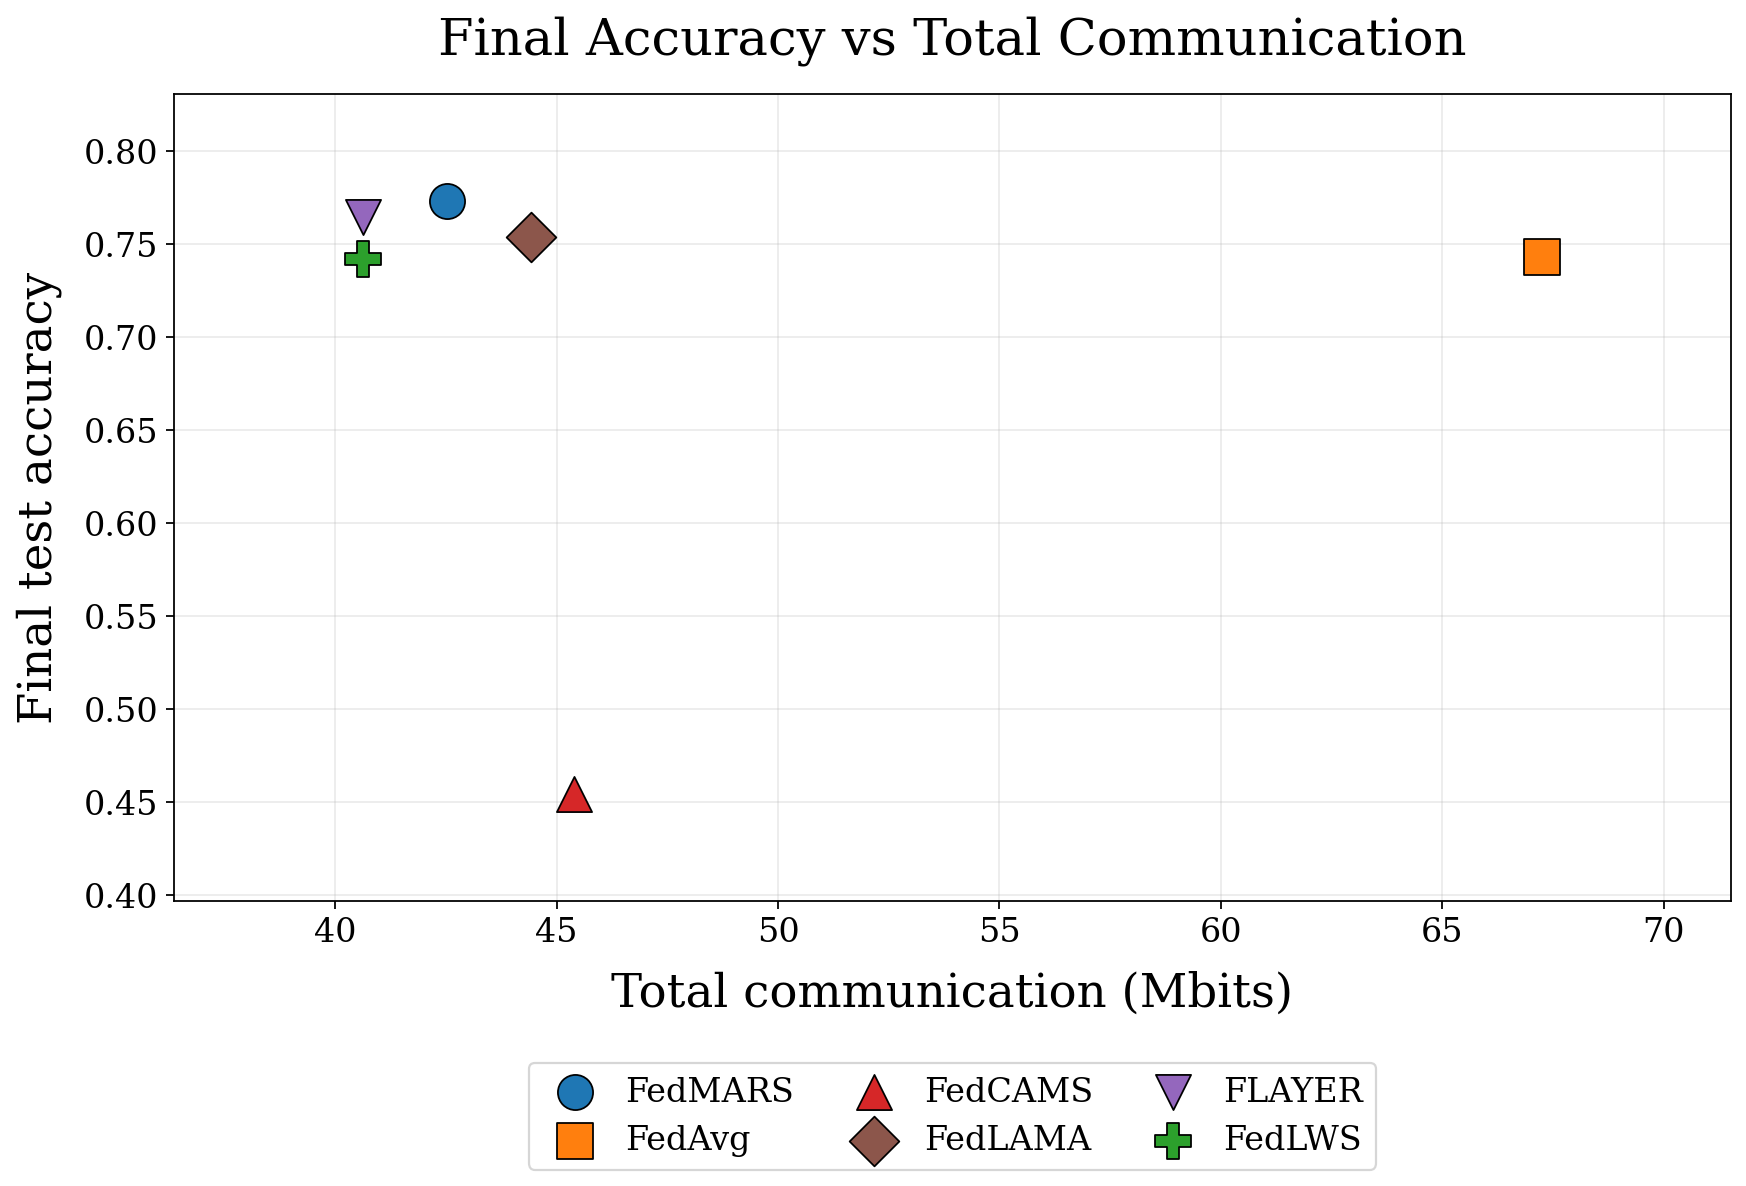

### Dataset: Iris

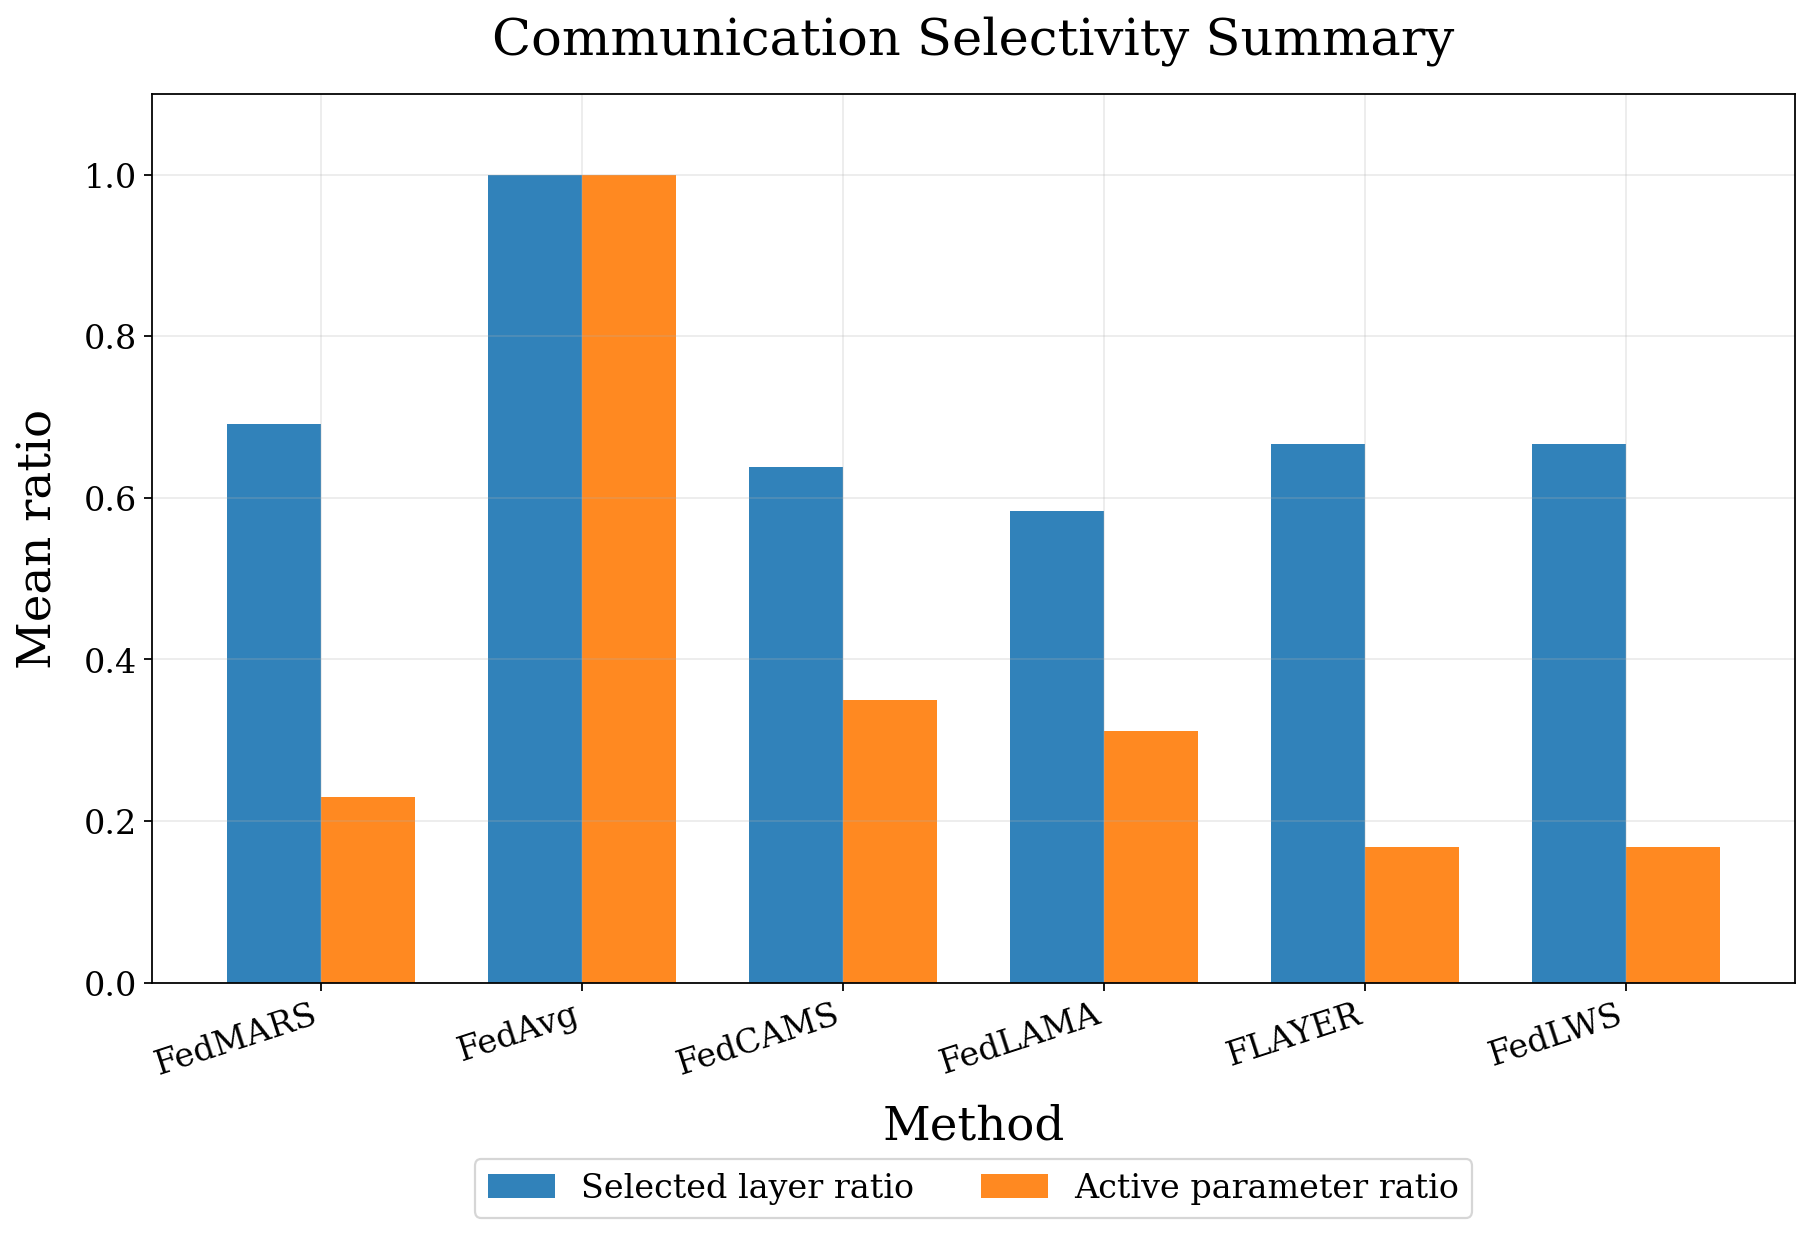

### Dataset: Balance Scale

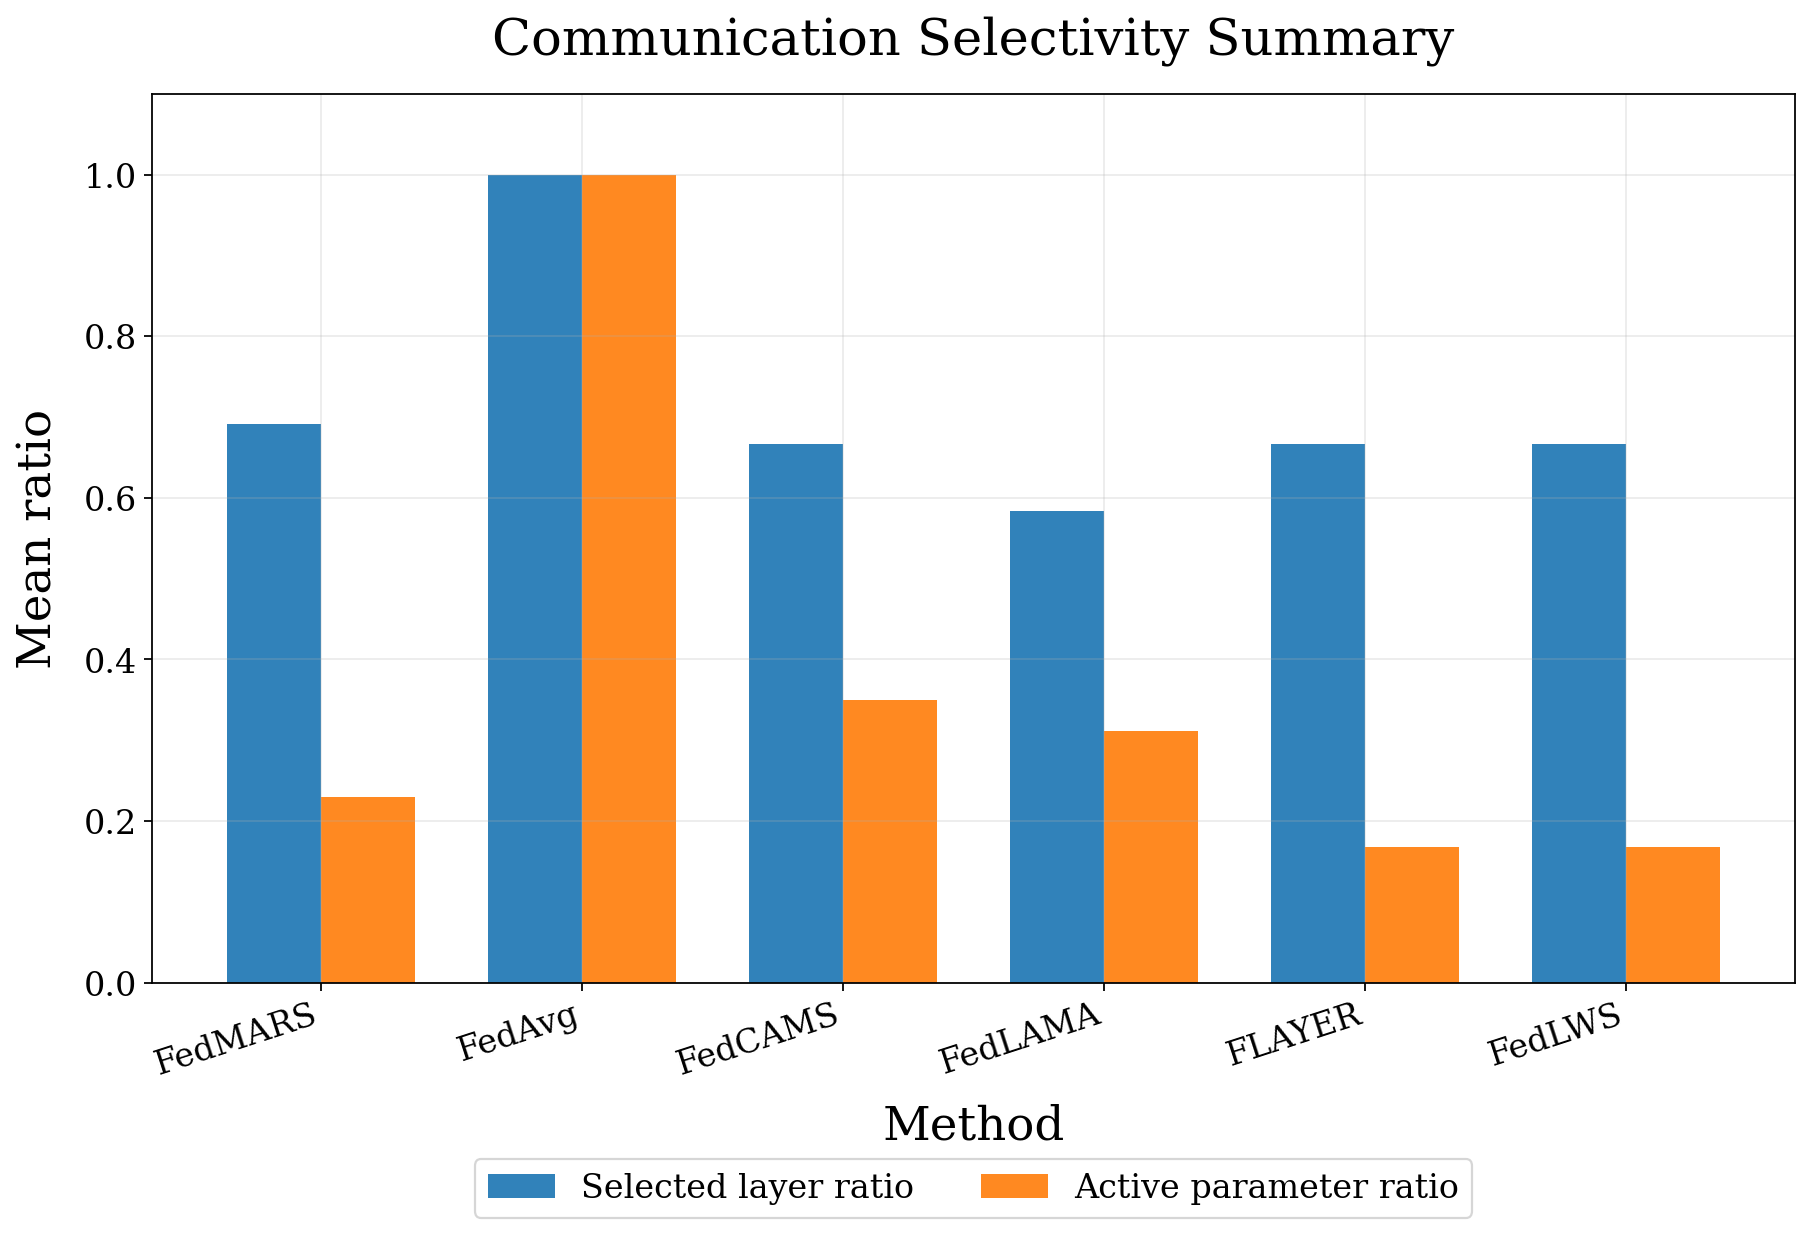

### Dataset: Vertebral Column

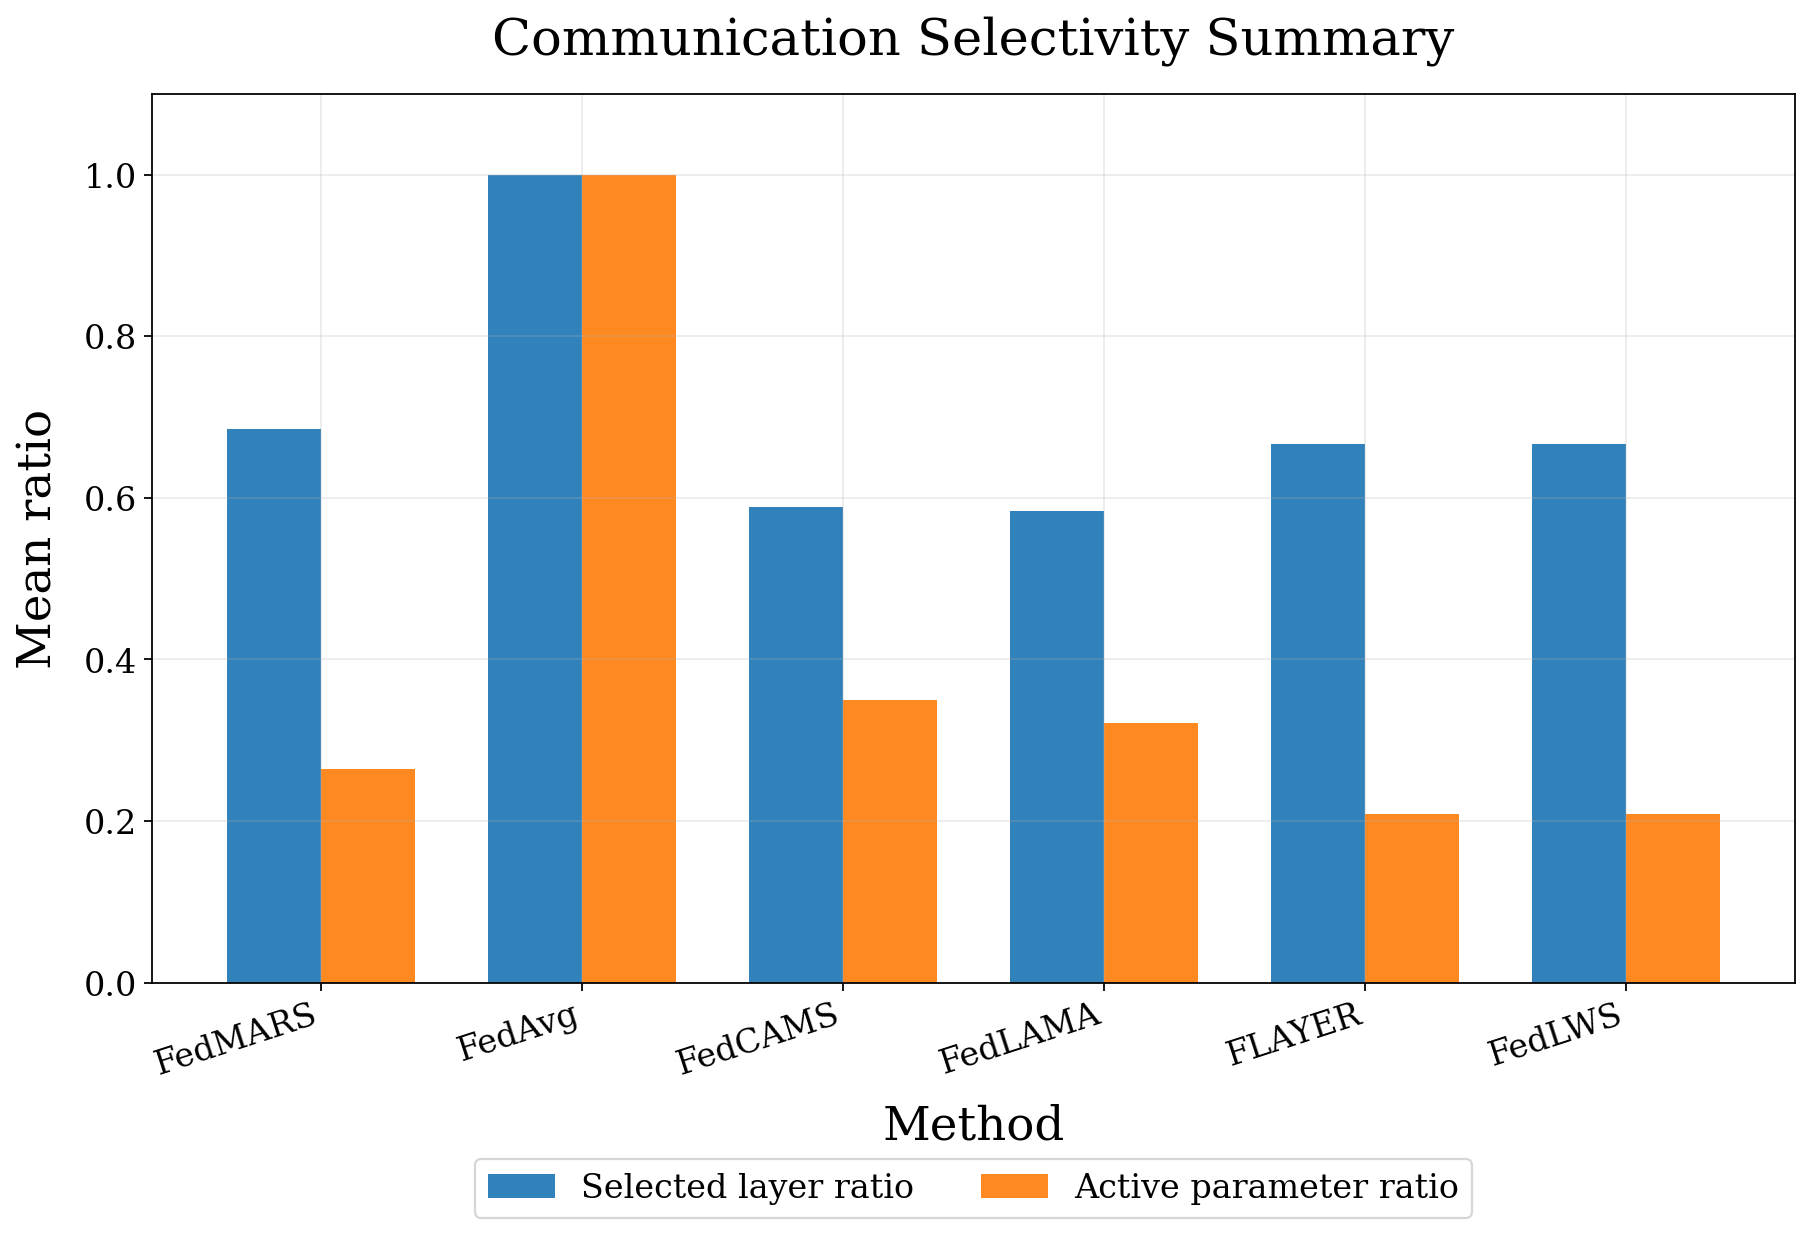

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

METHOD_ORDER = ["FedMARS", "FedAvg", "FedCAMS", "FedLAMA", "FLAYER", "FedLWS"]

METHOD_COLORS = {
    "FedMARS": "#1f77b4",
    "FedAvg": "#ff7f0e",
    "FedCAMS": "#d62728",
    "FedLAMA": "#8c564b",
    "FLAYER": "#9467bd",
    "FedLWS": "#2ca02c",
}

METHOD_MARKERS = {
    "FedMARS": "o",
    "FedAvg": "s",
    "FedCAMS": "^",
    "FedLAMA": "D",
    "FLAYER": "v",
    "FedLWS": "P",
}

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.size": 16,
    "axes.titlesize": 23,
    "axes.labelsize": 21,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

if "combined_summary_df" in globals():
    plot_summary = combined_summary_df.copy()
elif "all_dataset_summaries" in globals() and len(all_dataset_summaries) > 0:
    plot_summary = pd.concat(all_dataset_summaries, ignore_index=True)
elif "summary_df" in globals():
    plot_summary = summary_df.copy()
    if "dataset_name" not in plot_summary.columns:
        plot_summary.insert(0, "dataset_name", "Iris")
else:
    raise RuntimeError("No summary dataframe found. Run Validation 3 first.")

needed_cols = [
    "dataset_name",
    "method",
    "final_test_accuracy_mean",
    "total_bits_mean",
    "mean_selected_layer_ratio",
    "mean_active_parameter_ratio",
]
missing = [c for c in needed_cols if c not in plot_summary.columns]
if missing:
    raise RuntimeError(f"Missing columns in summary dataframe: {missing}")

plot_summary = plot_summary[plot_summary["method"].isin(METHOD_ORDER)].copy()
plot_summary["dataset_name"] = plot_summary["dataset_name"].astype(str)

if plot_summary["total_bits_mean"].median() > 1e5:
    plot_summary["total_comm_plot"] = plot_summary["total_bits_mean"] / 1e6
    comm_label = "Total communication (Mbits)"
else:
    plot_summary["total_comm_plot"] = plot_summary["total_bits_mean"]
    comm_label = "Total communication"

dataset_order = ["Iris", "Balance Scale", "Vertebral Column"]
datasets = [d for d in dataset_order if d in plot_summary["dataset_name"].unique()]

for dataset_name in datasets:
    display(Markdown(f"### Dataset: {dataset_name}"))

    sub = plot_summary[plot_summary["dataset_name"] == dataset_name].copy()
    sub["method"] = pd.Categorical(sub["method"], METHOD_ORDER, ordered=True)
    sub = sub.sort_values("method")

    fig, ax = plt.subplots(figsize=(10.8, 7.3), constrained_layout=True)

    for _, row in sub.iterrows():
        method = str(row["method"])
        ax.scatter(
            row["total_comm_plot"],
            row["final_test_accuracy_mean"],
            s=250,
            color=METHOD_COLORS[method],
            marker=METHOD_MARKERS[method],
            edgecolor="black",
            linewidth=0.8,
            label=method,
            zorder=3,
        )

    x_min = sub["total_comm_plot"].min()
    x_max = sub["total_comm_plot"].max()
    y_min = sub["final_test_accuracy_mean"].min()
    y_max = sub["final_test_accuracy_mean"].max()

    x_pad = max((x_max - x_min) * 0.16, 1.0)
    y_pad = max((y_max - y_min) * 0.18, 0.04)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))

    ax.set_title("Final Accuracy vs Total Communication", pad=18)
    ax.set_xlabel(comm_label, labelpad=10)
    ax.set_ylabel("Final test accuracy", labelpad=10)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=3,
        frameon=True,
        columnspacing=1.4,
        handletextpad=0.5,
    )

    safe_name = dataset_name.lower().replace(" ", "_")
    plt.savefig(
        f"v3_final_accuracy_vs_total_communication_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"v3_final_accuracy_vs_total_communication_{safe_name}.pdf",
        bbox_inches="tight",
    )
    plt.show()


for dataset_name in datasets:
    display(Markdown(f"### Dataset: {dataset_name}"))

    sub = plot_summary[plot_summary["dataset_name"] == dataset_name].copy()
    sub["method"] = pd.Categorical(sub["method"], METHOD_ORDER, ordered=True)
    sub = sub.sort_values("method")

    fig, ax = plt.subplots(figsize=(11.2, 7.6), constrained_layout=True)

    x = np.arange(len(sub))
    width = 0.36

    ax.bar(
        x - width / 2,
        sub["mean_selected_layer_ratio"],
        width=width,
        label="Selected layer ratio",
        color="#1f77b4",
        alpha=0.92,
    )

    ax.bar(
        x + width / 2,
        sub["mean_active_parameter_ratio"],
        width=width,
        label="Active parameter ratio",
        color="#ff7f0e",
        alpha=0.92,
    )

    ax.set_title("Communication Selectivity Summary", pad=18)
    ax.set_xlabel("Method", labelpad=10)
    ax.set_ylabel("Mean ratio", labelpad=10)
    ax.set_ylim(0.0, 1.10)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["method"], rotation=18, ha="right")

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=2,
        frameon=True,
    )

    ax.grid(True, axis="y", alpha=0.25)

    safe_name = dataset_name.lower().replace(" ", "_")
    plt.savefig(
        f"v3_communication_selectivity_summary_{safe_name}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.savefig(
        f"v3_communication_selectivity_summary_{safe_name}.pdf",
        bbox_inches="tight",
    )
    plt.show()

**Combined**

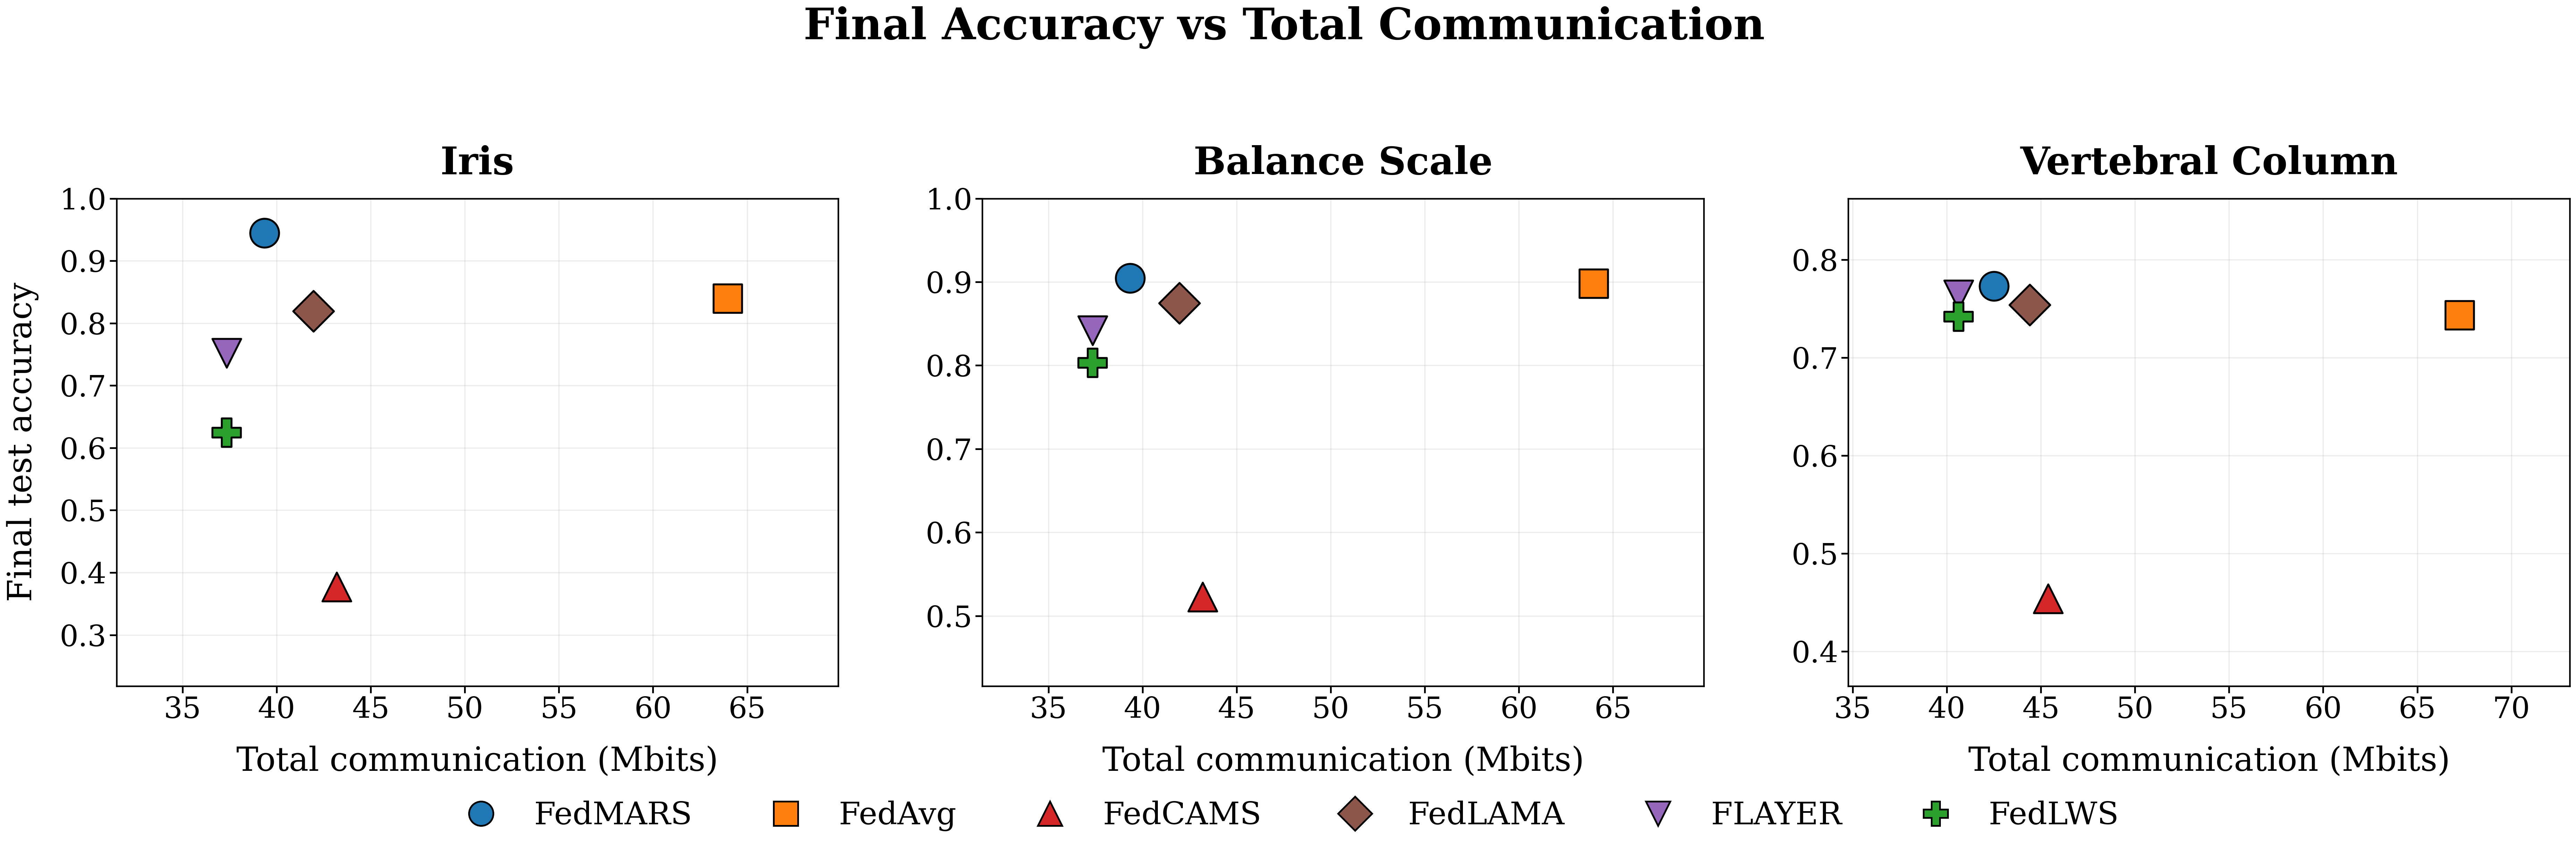

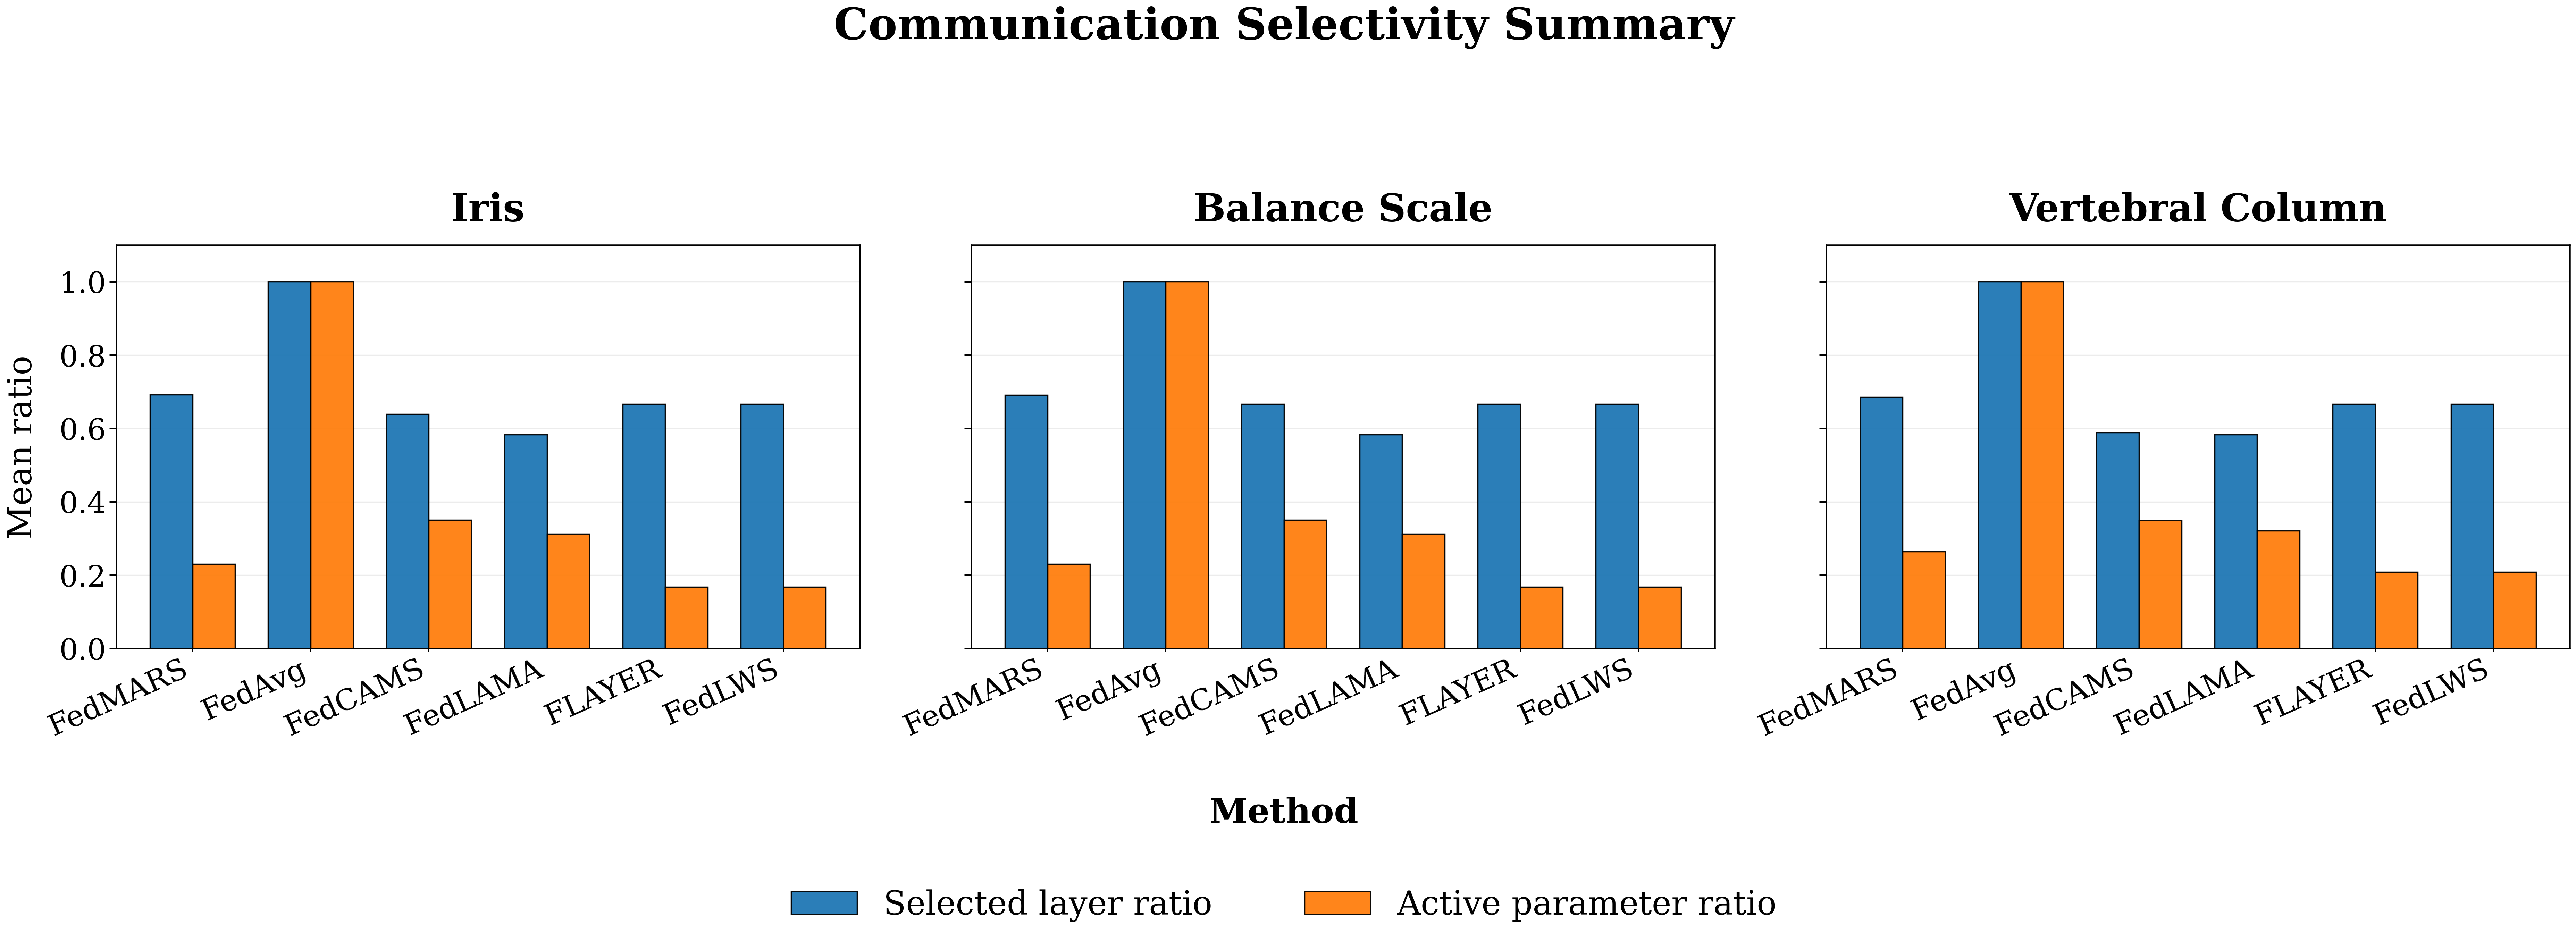

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

METHOD_ORDER = ["FedMARS", "FedAvg", "FedCAMS", "FedLAMA", "FLAYER", "FedLWS"]
DATASET_ORDER = ["Iris", "Balance Scale", "Vertebral Column"]

METHOD_COLORS = {
    "FedMARS": "#1f77b4",
    "FedAvg": "#ff7f0e",
    "FedCAMS": "#d62728",
    "FedLAMA": "#8c564b",
    "FLAYER": "#9467bd",
    "FedLWS": "#2ca02c",
}

METHOD_MARKERS = {
    "FedMARS": "o",
    "FedAvg": "s",
    "FedCAMS": "^",
    "FedLAMA": "D",
    "FLAYER": "v",
    "FedLWS": "P",
}

if "combined_summary_df" in globals():
    plot_summary = combined_summary_df.copy()
elif "all_dataset_summaries" in globals() and len(all_dataset_summaries) > 0:
    plot_summary = pd.concat(all_dataset_summaries, ignore_index=True)
elif "summary_df" in globals():
    plot_summary = summary_df.copy()
    if "dataset_name" not in plot_summary.columns:
        plot_summary.insert(0, "dataset_name", "Iris")
else:
    raise RuntimeError("No summary dataframe found. Run Validation 3 first.")

needed_cols = [
    "dataset_name",
    "method",
    "final_test_accuracy_mean",
    "total_bits_mean",
    "mean_selected_layer_ratio",
    "mean_active_parameter_ratio",
]
missing = [c for c in needed_cols if c not in plot_summary.columns]
if missing:
    raise RuntimeError(f"Missing columns in summary dataframe: {missing}")

plot_summary = plot_summary.copy()
plot_summary["dataset_name"] = plot_summary["dataset_name"].astype(str)
plot_summary["method"] = plot_summary["method"].astype(str)

plot_summary = plot_summary[
    plot_summary["dataset_name"].isin(DATASET_ORDER)
    & plot_summary["method"].isin(METHOD_ORDER)
].copy()

for c in [
    "final_test_accuracy_mean",
    "total_bits_mean",
    "mean_selected_layer_ratio",
    "mean_active_parameter_ratio",
]:
    plot_summary[c] = pd.to_numeric(plot_summary[c], errors="coerce")

plot_summary = plot_summary.dropna(
    subset=[
        "final_test_accuracy_mean",
        "total_bits_mean",
        "mean_selected_layer_ratio",
        "mean_active_parameter_ratio",
    ]
).copy()

if plot_summary["total_bits_mean"].median() > 1e5:
    plot_summary["total_comm_plot"] = plot_summary["total_bits_mean"] / 1e6
    comm_label = "Total communication (Mbits)"
else:
    plot_summary["total_comm_plot"] = plot_summary["total_bits_mean"]
    comm_label = "Total communication (Mbits)"

datasets = [d for d in DATASET_ORDER if d in plot_summary["dataset_name"].unique()]
if not datasets:
    raise RuntimeError("No Iris / Balance Scale / Vertebral Column rows found.")

plt.rcParams.update({
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 34,
    "axes.titlesize": 42,
    "axes.labelsize": 38,
    "xtick.labelsize": 33,
    "ytick.labelsize": 33,
    "legend.fontsize": 34,
    "axes.grid": True,
    "grid.alpha": 0.24,
})

# ============================================================
# FIGURE 1: COMBINED FINAL ACCURACY VS TOTAL COMMUNICATION
# ============================================================

fig, axes = plt.subplots(
    1,
    len(datasets),
    figsize=(42, 15),
    sharey=False
)

if len(datasets) == 1:
    axes = [axes]

fig.subplots_adjust(
    top=0.76,
    bottom=0.24,
    left=0.055,
    right=0.99,
    wspace=0.20
)

fig.suptitle(
    "Final Accuracy vs Total Communication",
    fontsize=50,
    fontweight="bold",
    y=0.965
)

for ax, dataset_name in zip(axes, datasets):
    sub = plot_summary[plot_summary["dataset_name"] == dataset_name].copy()
    sub["method"] = pd.Categorical(sub["method"], METHOD_ORDER, ordered=True)
    sub = sub.sort_values("method")

    for _, row in sub.iterrows():
        method = str(row["method"])
        ax.scatter(
            row["total_comm_plot"],
            row["final_test_accuracy_mean"],
            s=1100,
            color=METHOD_COLORS[method],
            marker=METHOD_MARKERS[method],
            edgecolor="black",
            linewidth=2.2,
            zorder=5,
        )

    x_min = sub["total_comm_plot"].min()
    x_max = sub["total_comm_plot"].max()
    y_min = sub["final_test_accuracy_mean"].min()
    y_max = sub["final_test_accuracy_mean"].max()

    x_pad = max((x_max - x_min) * 0.22, 2.5)
    y_pad = max((y_max - y_min) * 0.28, 0.08)

    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))

    ax.set_title(dataset_name, fontsize=44, fontweight="bold", pad=28)
    ax.set_xlabel(comm_label, fontsize=38, labelpad=24)
    ax.tick_params(axis="both", labelsize=34, width=2.0, length=8)
    ax.grid(True, alpha=0.24, linewidth=1.4)
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

axes[0].set_ylabel("Final test accuracy", fontsize=38, labelpad=24)

scatter_handles = [
    Line2D(
        [0], [0],
        marker=METHOD_MARKERS[m],
        color="w",
        markerfacecolor=METHOD_COLORS[m],
        markeredgecolor="black",
        markeredgewidth=2.0,
        markersize=28,
        linestyle="None",
        label=m
    )
    for m in METHOD_ORDER
]

fig.legend(
    handles=scatter_handles,
    labels=METHOD_ORDER,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.055),
    ncol=6,
    frameon=False,
    fontsize=36,
    columnspacing=2.0,
    handletextpad=0.7,
)

plt.savefig(
    "v3_combined_final_accuracy_vs_total_communication_HUGE_READABLE.png",
    dpi=600,
    bbox_inches="tight",
)
plt.savefig(
    "v3_combined_final_accuracy_vs_total_communication_HUGE_READABLE.pdf",
    bbox_inches="tight",
)
plt.savefig(
    "v3_combined_final_accuracy_vs_total_communication_HUGE_READABLE.svg",
    bbox_inches="tight",
)
plt.show()


# ============================================================
# FIGURE 2: COMBINED COMMUNICATION SELECTIVITY BAR PLOT
# ============================================================

fig, axes = plt.subplots(
    1,
    len(datasets),
    figsize=(42, 17),
    sharey=True
)

if len(datasets) == 1:
    axes = [axes]

fig.subplots_adjust(
    top=0.74,
    bottom=0.36,
    left=0.055,
    right=0.99,
    wspace=0.15
)

fig.suptitle(
    "Communication Selectivity Summary",
    fontsize=50,
    fontweight="bold",
    y=0.965
)

for ax, dataset_name in zip(axes, datasets):
    sub = plot_summary[plot_summary["dataset_name"] == dataset_name].copy()
    sub["method"] = pd.Categorical(sub["method"], METHOD_ORDER, ordered=True)
    sub = sub.sort_values("method")

    x = np.arange(len(sub))
    width = 0.36

    ax.bar(
        x - width / 2,
        sub["mean_selected_layer_ratio"],
        width=width,
        label="Selected layer ratio",
        color="#1f77b4",
        alpha=0.95,
        edgecolor="black",
        linewidth=1.4,
    )

    ax.bar(
        x + width / 2,
        sub["mean_active_parameter_ratio"],
        width=width,
        label="Active parameter ratio",
        color="#ff7f0e",
        alpha=0.95,
        edgecolor="black",
        linewidth=1.4,
    )

    ax.set_title(dataset_name, fontsize=44, fontweight="bold", pad=28)
    ax.set_xticks(x)
    ax.set_xticklabels(
        sub["method"],
        rotation=24,
        ha="right",
        fontsize=34
    )

    ax.tick_params(axis="y", labelsize=34, width=2.0, length=8)
    ax.set_ylim(0.0, 1.10)
    ax.grid(True, axis="y", alpha=0.24, linewidth=1.4)
    ax.grid(False, axis="x")
    ax.set_axisbelow(True)

    for spine in ax.spines.values():
        spine.set_linewidth(1.8)

axes[0].set_ylabel("Mean ratio", fontsize=38, labelpad=24)

fig.text(
    0.5,
    0.205,
    "Method",
    ha="center",
    va="center",
    fontsize=40,
    fontweight="bold",
)

bar_handles, bar_labels = axes[0].get_legend_handles_labels()
fig.legend(
    bar_handles,
    bar_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.075),
    ncol=2,
    frameon=False,
    fontsize=38,
    columnspacing=2.8,
    handletextpad=0.8,
)

plt.savefig(
    "v3_combined_communication_selectivity_summary_HUGE_READABLE.png",
    dpi=600,
    bbox_inches="tight",
)
plt.savefig(
    "v3_combined_communication_selectivity_summary_HUGE_READABLE.pdf",
    bbox_inches="tight",
)
plt.savefig(
    "v3_combined_communication_selectivity_summary_HUGE_READABLE.svg",
    bbox_inches="tight",
)
plt.show()